# PCT Evaluation

Load and test trained models, and show various evaluation metrics.

Note: Does no longer use original PCT data.

## Prep

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
# Paths, folders
import os

REPO_PATH = '/content/pointcloud-bench'
DRIVE_PATH = '/content/drive/MyDrive/pointcloud-bench'
results_dir = os.path.join(DRIVE_PATH, 'results')
os.makedirs(results_dir, exist_ok=True)


In [4]:
# Get repo
!git clone --recursive --single-branch --branch PCT-retrain https://github.com/DavidClaszen/pointcloud-bench {REPO_PATH}
%cd {REPO_PATH}
%pip install -r envs/pct/requirements.txt

Cloning into '/content/pointcloud-bench'...
remote: Enumerating objects: 314, done.
remote: Counting objects: 100% (57/57), done.
remote: Compressing objects: 100% (21/21), done.
remote: Total 314 (delta 39), reused 39 (delta 36), pack-reused 257 (from 1)
Receiving objects: 100% (314/314), 34.14 MiB | 9.67 MiB/s, done.
Resolving deltas: 100% (135/135), done.
Submodule 'repos/PAPNet' (https://github.com/DavidClaszen/PAPNet.git) registered for path 'repos/PAPNet'
Submodule 'repos/Point-Transformers' (https://github.com/DavidClaszen/Point-Transformers.git) registered for path 'repos/Point-Transformers'
Cloning into '/content/pointcloud-bench/repos/PAPNet'...
remote: Enumerating objects: 133, done.        
remote: Counting objects: 100% (133/133), done.        
remote: Compressing objects: 100% (105/105), done.        
remote: Total 133 (delta 55), reused 85 (delta 27), pack-reused 0 (from 0)        
Receiving objects: 100% (133/133), 9.66 MiB | 9.76 MiB/s, done.
Resolving deltas: 100% (55

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, confusion_matrix
from hydra import initialize_config_dir, compose
from omegaconf import OmegaConf
from IPython.display import display, HTML
from tqdm import tqdm

In [6]:
# Copy select files from Google Drive to the repo dataset folder
!rsync -avP {DRIVE_PATH}/datasets/fullmodelnet40.tar.gz {REPO_PATH}/datasets
!rsync -avP {DRIVE_PATH}/datasets/partialmodelnet40.tar.gz {REPO_PATH}/datasets
!rsync -avP {DRIVE_PATH}/datasets/pm40_extreme_partiality.tar.gz {REPO_PATH}/datasets

# Extract zip files
%cd {REPO_PATH}
!tar -xvzf datasets/fullmodelnet40.tar.gz -C datasets
!tar -xvzf datasets/partialmodelnet40.tar.gz -C datasets
!tar -xvzf datasets/pm40_extreme_partiality.tar.gz -C datasets

sending incremental file list
fullmodelnet40.tar.gz
  1,833,210,387 100%   55.22MB/s    0:00:31 (xfr#1, to-chk=0/1)

sent 1,833,658,058 bytes  received 35 bytes  54,736,062.48 bytes/sec
total size is 1,833,210,387  speedup is 1.00
sending incremental file list
partialmodelnet40.tar.gz
  2,162,130,396 100%   48.87MB/s    0:00:42 (xfr#1, to-chk=0/1)

sent 2,162,658,366 bytes  received 35 bytes  49,716,285.08 bytes/sec
total size is 2,162,130,396  speedup is 1.00
sending incremental file list
pm40_extreme_partiality.tar.gz
  8,334,013,260 100%   47.81MB/s    0:02:46 (xfr#1, to-chk=0/1)

sent 8,336,048,044 bytes  received 35 bytes  49,472,095.42 bytes/sec
total size is 8,334,013,260  speedup is 1.00
/content/pointcloud-bench
fullmodelnet40/
fullmodelnet40/test_filenames.txt
fullmodelnet40/test_gt_rot.npy
fullmodelnet40/test_gt_tra.npy
fullmodelnet40/test_labels.npy
fullmodelnet40/test_points.npy
fullmodelnet40/train_filenames.txt
fullmodelnet40/train_gt_rot.npy
fullmodelnet40/train_gt_tra.

## Get Predictions

Upload checkpoints, get test results, visualize and analyze.

You can get the trained model checkpoints from [this folder](https://drive.google.com/drive/folders/13TIEUMSkxi-MxY_Y-kTkAsEcRP5OgAR3?usp=sharing).

Copy those files into your own Google Drive and, if necessary, change the first path in the code below. Contents:

- Evaluated in this notebook:
    - pct_p50.pth:      PCT trained on partial50 from PAPNet
    - pct_pfull.pth:    PCT trained on full version of PAPNet
- Archived:
    - pct_pct.pth:      PCT trained on the original dataset used for PCT
    - pct_pct_p50:      PCT trained on the original dataset used for PCT, tuned on partial50 from PAPNet
    - pct_p50_pct.pth:  PCT trained on partial 50 from PAPNet, tuned on original dataset used for PCT

In [9]:
!rsync -avP {DRIVE_PATH}/checkpoints/. {REPO_PATH}/checkpoints

sending incremental file list
./
pct_p50.pth
     34,642,219 100%  229.21MB/s    0:00:00 (xfr#1, to-chk=4/6)
pct_p50_pct.pth
     34,642,524 100%   73.25MB/s    0:00:00 (xfr#2, to-chk=3/6)
pct_pct.pth
     34,642,219 100%   50.67MB/s    0:00:00 (xfr#3, to-chk=2/6)
pct_pct_p50.pth
     34,641,609 100%   30.59MB/s    0:00:01 (xfr#4, to-chk=1/6)
pct_pfull.pth
     34,642,219 100%  110.86MB/s    0:00:00 (xfr#5, to-chk=0/6)

sent 173,253,435 bytes  received 114 bytes  69,301,419.60 bytes/sec
total size is 173,210,790  speedup is 1.00


In [10]:
%cd /content/pointcloud-bench/repos/Point-Transformers/
!python test_cls.py --help

/content/pointcloud-bench/repos/Point-Transformers
test_cls is powered by Hydra.

== Configuration groups ==
Compose your configuration from those groups (group=option)

model: Hengshuang, Menghao, Nico


== Config ==
Override anything in the config (foo.bar=value)

model:
  name: Menghao
batch_size: 16
epoch: 200
learning_rate: 0.001
gpu: 0
num_point: 1024
optimizer: Adam
weight_decay: 0.0001
normal: true
use_papnet_loader: false
workers: 2
step_size: 50
data_path: ../../datasets/modelnet40_normal_resampled/
checkpoint_path: best_model.pth
partiality: ''


Powered by Hydra (https://hydra.cc)
Use --hydra-help to view Hydra specific help




In [11]:
# Function for inference

from test_cls import get_predictions

%cd {REPO_PATH}/repos/Point-Transformers/
config_dir = f'{REPO_PATH}/repos/Point-Transformers/config'


def test_pct(
    data_folder: str = 'partialmodelnet40',
    checkpoint: str = 'pct_p50',
    config_dir: str = config_dir,
    partiality: str = ''
) -> tuple[np.array, np.array]:
    """Gets predictions from pretrained PCT model.

    Args:
        data_folder (str, optional): Dataset folder to test on.
            Defaults to 'partialmodelnet40'.
        checkpoint (str, optional): Checkpoint name; omit extension.
            Defaults to 'pct_p50'.
        config_dir (str, optional): Where the model configs reside.
            Only necessary to run, but not used. Defaults to config_dir.
        partiality (str, optional): Used only for extreme partiality
            datasets with non-standard filenames. Use '_10', '_20',
            '_30', '_40'.

    Returns:
        tuple(np.array, np.array): Tuple of predictions and base truths
    """
    if data_folder in ['partialmodelnet40', 'pm40_partiality_level', 'fullmodelnet40']:
        papnet_loader = 'true'
    else: papnet_loader = 'false'

    with initialize_config_dir(config_dir=config_dir, version_base='1.2'):
        cfg = compose(
            config_name='cls',
            overrides=[
                f'data_path=../../datasets/{data_folder}/',
                f'checkpoint_path=../../checkpoints/{checkpoint}.pth',
                f'use_papnet_loader={papnet_loader}',
                f'partiality={partiality}'
            ],
        )
    OmegaConf.set_struct(cfg, False)
    y_true, y_pred = get_predictions(cfg)
    accuracy = accuracy_score(y_true, y_pred)
    print(f'Accuracy: {accuracy:.4f} for dataset {data_folder} and model {checkpoint}')
    return (y_true, y_pred)

/content/pointcloud-bench/repos/Point-Transformers


In [13]:
# Train PCT on fullmodelnet40, test PCT on fullmodelnet40 (full, full)
y_true, y_pred = test_pct(
    data_folder='fullmodelnet40',
    checkpoint='pct_pfull'
  )

result_df = pd.DataFrame({
    'y_true': y_true,
    'full_full': y_pred
})

The size of test data is 2468
Total number of parameters: 2876328
Model loaded with 34 epochs
# iterations (batches): 155
Average inference time per batch: 162.165 ms
Average inference time per sample: 10.184580 ms
Accuracy: 0.8529 for dataset fullmodelnet40 and model pct_pfull


In [15]:
# PCT train full, test partial

y_true, y_pred = test_pct(
    data_folder='partialmodelnet40',
    checkpoint='pct_pfull'
  )
result_df['full_partial50'] = y_pred

The size of test data is 2468
Total number of parameters: 2876328
Model loaded with 34 epochs
# iterations (batches): 155
Average inference time per batch: 126.093 ms
Average inference time per sample: 7.919145 ms
Accuracy: 0.1592 for dataset partialmodelnet40 and model pct_pfull


In [16]:
# Trained on partial50, tested partial50 (partial, partial)

y_true, y_pred = test_pct(data_folder='partialmodelnet40', checkpoint='pct_p50')
result_df['partial50_partial50'] = y_pred

The size of test data is 2468
Total number of parameters: 2876328
Model loaded with 38 epochs
# iterations (batches): 155
Average inference time per batch: 130.692 ms
Average inference time per sample: 8.207990 ms
Accuracy: 0.7954 for dataset partialmodelnet40 and model pct_p50


In [17]:
# Trained on partial50, tested fullmodelnet40 (partial, full)

y_true, y_pred = test_pct(data_folder='fullmodelnet40', checkpoint='pct_p50')
result_df['partial50_full'] = y_pred

The size of test data is 2468
Total number of parameters: 2876328
Model loaded with 38 epochs
# iterations (batches): 155
Average inference time per batch: 126.684 ms
Average inference time per sample: 7.956261 ms
Accuracy: 0.1459 for dataset fullmodelnet40 and model pct_p50


In [18]:
# Extreme partialities, full model

y_true, y_pred = test_pct(data_folder='pm40_partiality_level', checkpoint='pct_pfull', partiality='_40')
result_df['full_partial40'] = y_pred
y_true, y_pred = test_pct(data_folder='pm40_partiality_level', checkpoint='pct_pfull', partiality='_30')
result_df['full_partial30'] = y_pred
y_true, y_pred = test_pct(data_folder='pm40_partiality_level', checkpoint='pct_pfull', partiality='_20')
result_df['full_partial20'] = y_pred
y_true, y_pred = test_pct(data_folder='pm40_partiality_level', checkpoint='pct_pfull', partiality='_10')
result_df['full_partial10'] = y_pred

The size of test data is 2468
Total number of parameters: 2876328
Model loaded with 34 epochs
# iterations (batches): 155
Average inference time per batch: 165.587 ms
Average inference time per sample: 10.399536 ms
Accuracy: 0.1009 for dataset pm40_partiality_level and model pct_pfull
The size of test data is 2468
Total number of parameters: 2876328
Model loaded with 34 epochs
# iterations (batches): 155
Average inference time per batch: 127.654 ms
Average inference time per sample: 8.017191 ms
Accuracy: 0.0729 for dataset pm40_partiality_level and model pct_pfull
The size of test data is 2468
Total number of parameters: 2876328
Model loaded with 34 epochs
# iterations (batches): 155
Average inference time per batch: 125.436 ms
Average inference time per sample: 7.877890 ms
Accuracy: 0.0498 for dataset pm40_partiality_level and model pct_pfull
The size of test data is 2468
Total number of parameters: 2876328
Model loaded with 34 epochs
# iterations (batches): 155
Average inference time

In [19]:
# Extreme partialities, partial model

y_true, y_pred = test_pct(data_folder='pm40_partiality_level', checkpoint='pct_p50', partiality='_40')
result_df['partial50_partial40'] = y_pred
y_true, y_pred = test_pct(data_folder='pm40_partiality_level', checkpoint='pct_p50', partiality='_30')
result_df['partial50_partial30'] = y_pred
y_true, y_pred = test_pct(data_folder='pm40_partiality_level', checkpoint='pct_p50', partiality='_20')
result_df['partial50_partial20'] = y_pred
y_true, y_pred = test_pct(data_folder='pm40_partiality_level', checkpoint='pct_p50', partiality='_10')
result_df['partial50_partial10'] = y_pred


The size of test data is 2468
Total number of parameters: 2876328
Model loaded with 38 epochs
# iterations (batches): 155
Average inference time per batch: 135.940 ms
Average inference time per sample: 8.537557 ms
Accuracy: 0.6288 for dataset pm40_partiality_level and model pct_p50
The size of test data is 2468
Total number of parameters: 2876328
Model loaded with 38 epochs
# iterations (batches): 155
Average inference time per batch: 127.975 ms
Average inference time per sample: 8.037356 ms
Accuracy: 0.4279 for dataset pm40_partiality_level and model pct_p50
The size of test data is 2468
Total number of parameters: 2876328
Model loaded with 38 epochs
# iterations (batches): 155
Average inference time per batch: 134.357 ms
Average inference time per sample: 8.438143 ms
Accuracy: 0.2528 for dataset pm40_partiality_level and model pct_p50
The size of test data is 2468
Total number of parameters: 2876328
Model loaded with 38 epochs
# iterations (batches): 155
Average inference time per ba

## Accuracies

In [20]:
# Store results
results_dir = os.path.join(DRIVE_PATH, 'results')
os.makedirs(results_dir, exist_ok=True)
result_df.to_csv(os.path.join(results_dir, 'pct_results_2.csv'), index=False, sep=';')

# Table results
accuracies = []
columns = result_df.columns[1:]

for col in columns:
  accuracy = accuracy_score(y_true, result_df[col])
  accuracies.append(accuracy * 100)

accuracy_df = pd.DataFrame({
    'Trained On': columns,
    'Accuracy (%)': accuracies
})

accuracy_df[['Trained On', 'Tested On']] = accuracy_df['Trained On'].str.split('_', expand=True)
accuracy_df['Accuracy (%)'] = accuracy_df['Accuracy (%)'].map("{:.2f}".format)
accuracy_df = accuracy_df.sort_values(by=['Trained On', 'Tested On'])[['Trained On', 'Tested On', 'Accuracy (%)']].reset_index(drop=True)
display(HTML(accuracy_df.to_html()))

,Trained On,Tested On,Accuracy (%)
0,full,full,85.29
1,full,partial10,2.96
2,full,partial20,4.98
3,full,partial30,7.29
4,full,partial40,10.09
5,full,partial50,15.92
6,partial50,full,14.59
7,partial50,partial10,11.47
8,partial50,partial20,25.28
9,partial50,partial30,42.79


## Quick Visualization

In [21]:
# Load class names from dataset
class_names_path = os.path.join(REPO_PATH, 'datasets', 'partialmodelnet40', 'partialmodelnet40_shape_names.txt')
with open(class_names_path, 'r') as f:
    class_names = [line.strip() for line in f.readlines()]
    class_names = {i: name for i, name in enumerate(class_names)}

Drawing Confusion Matrices: 100%|██████████| 12/12 [00:36<00:00,  3.05s/it]


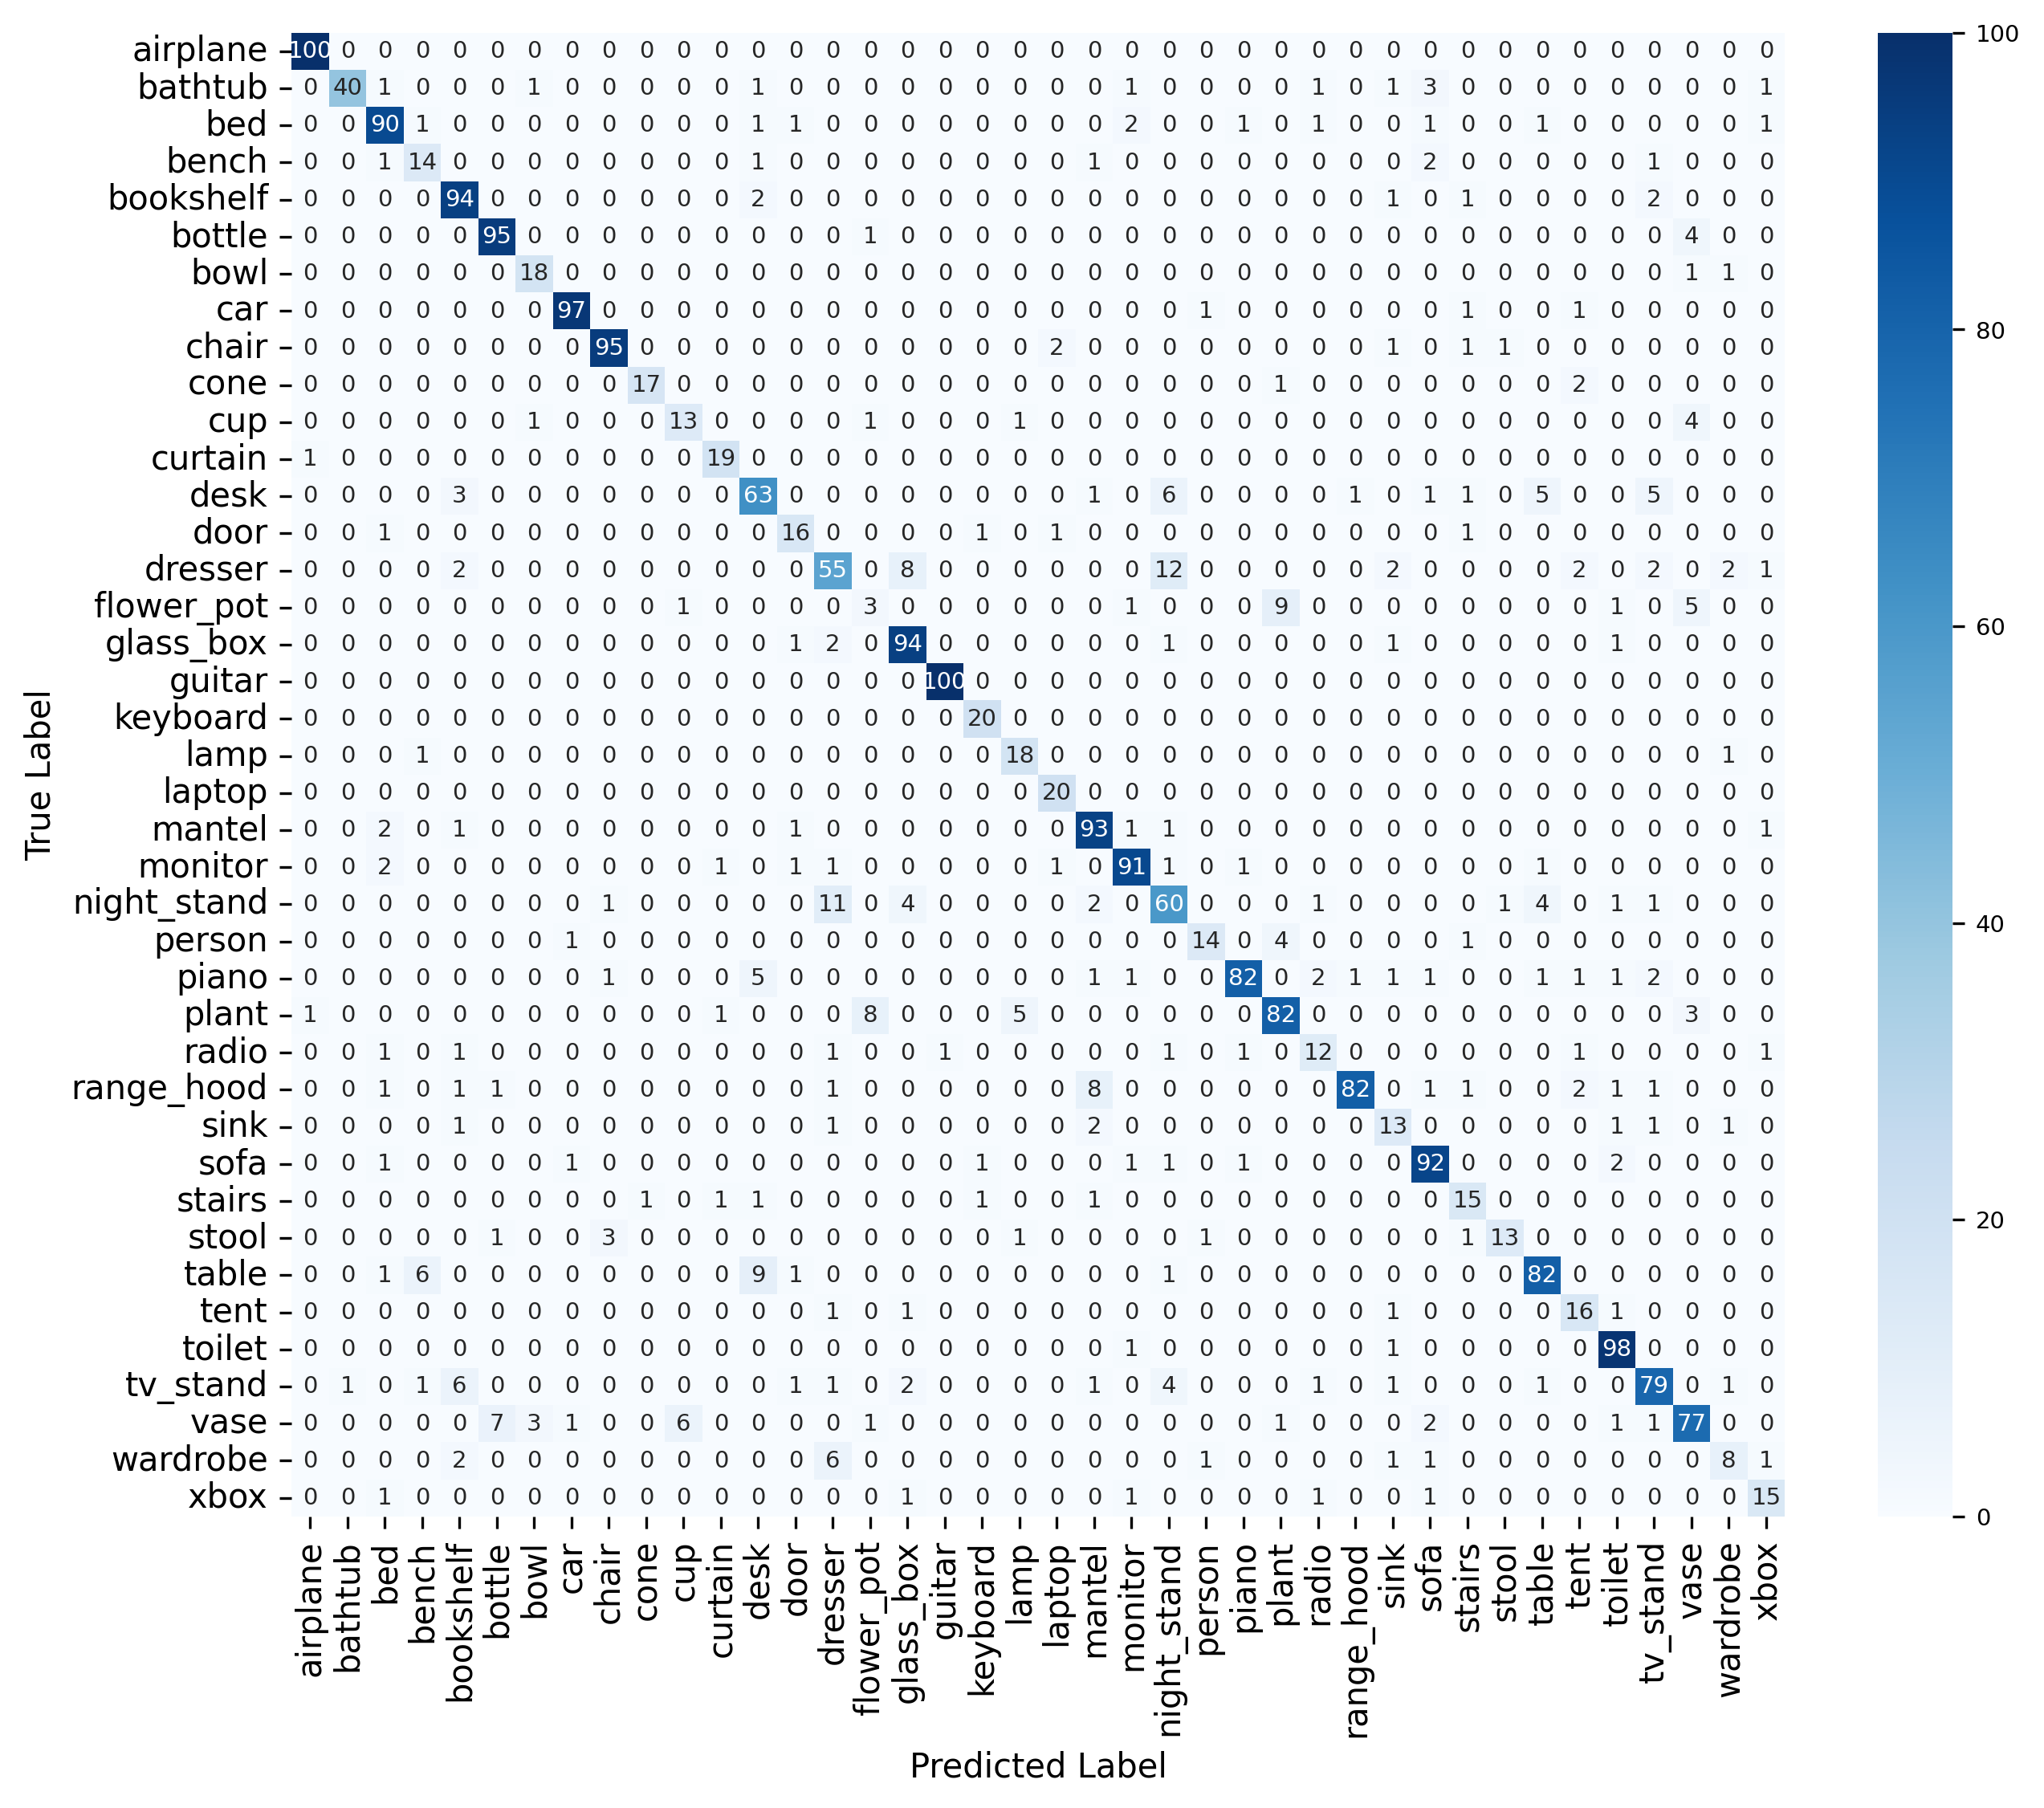

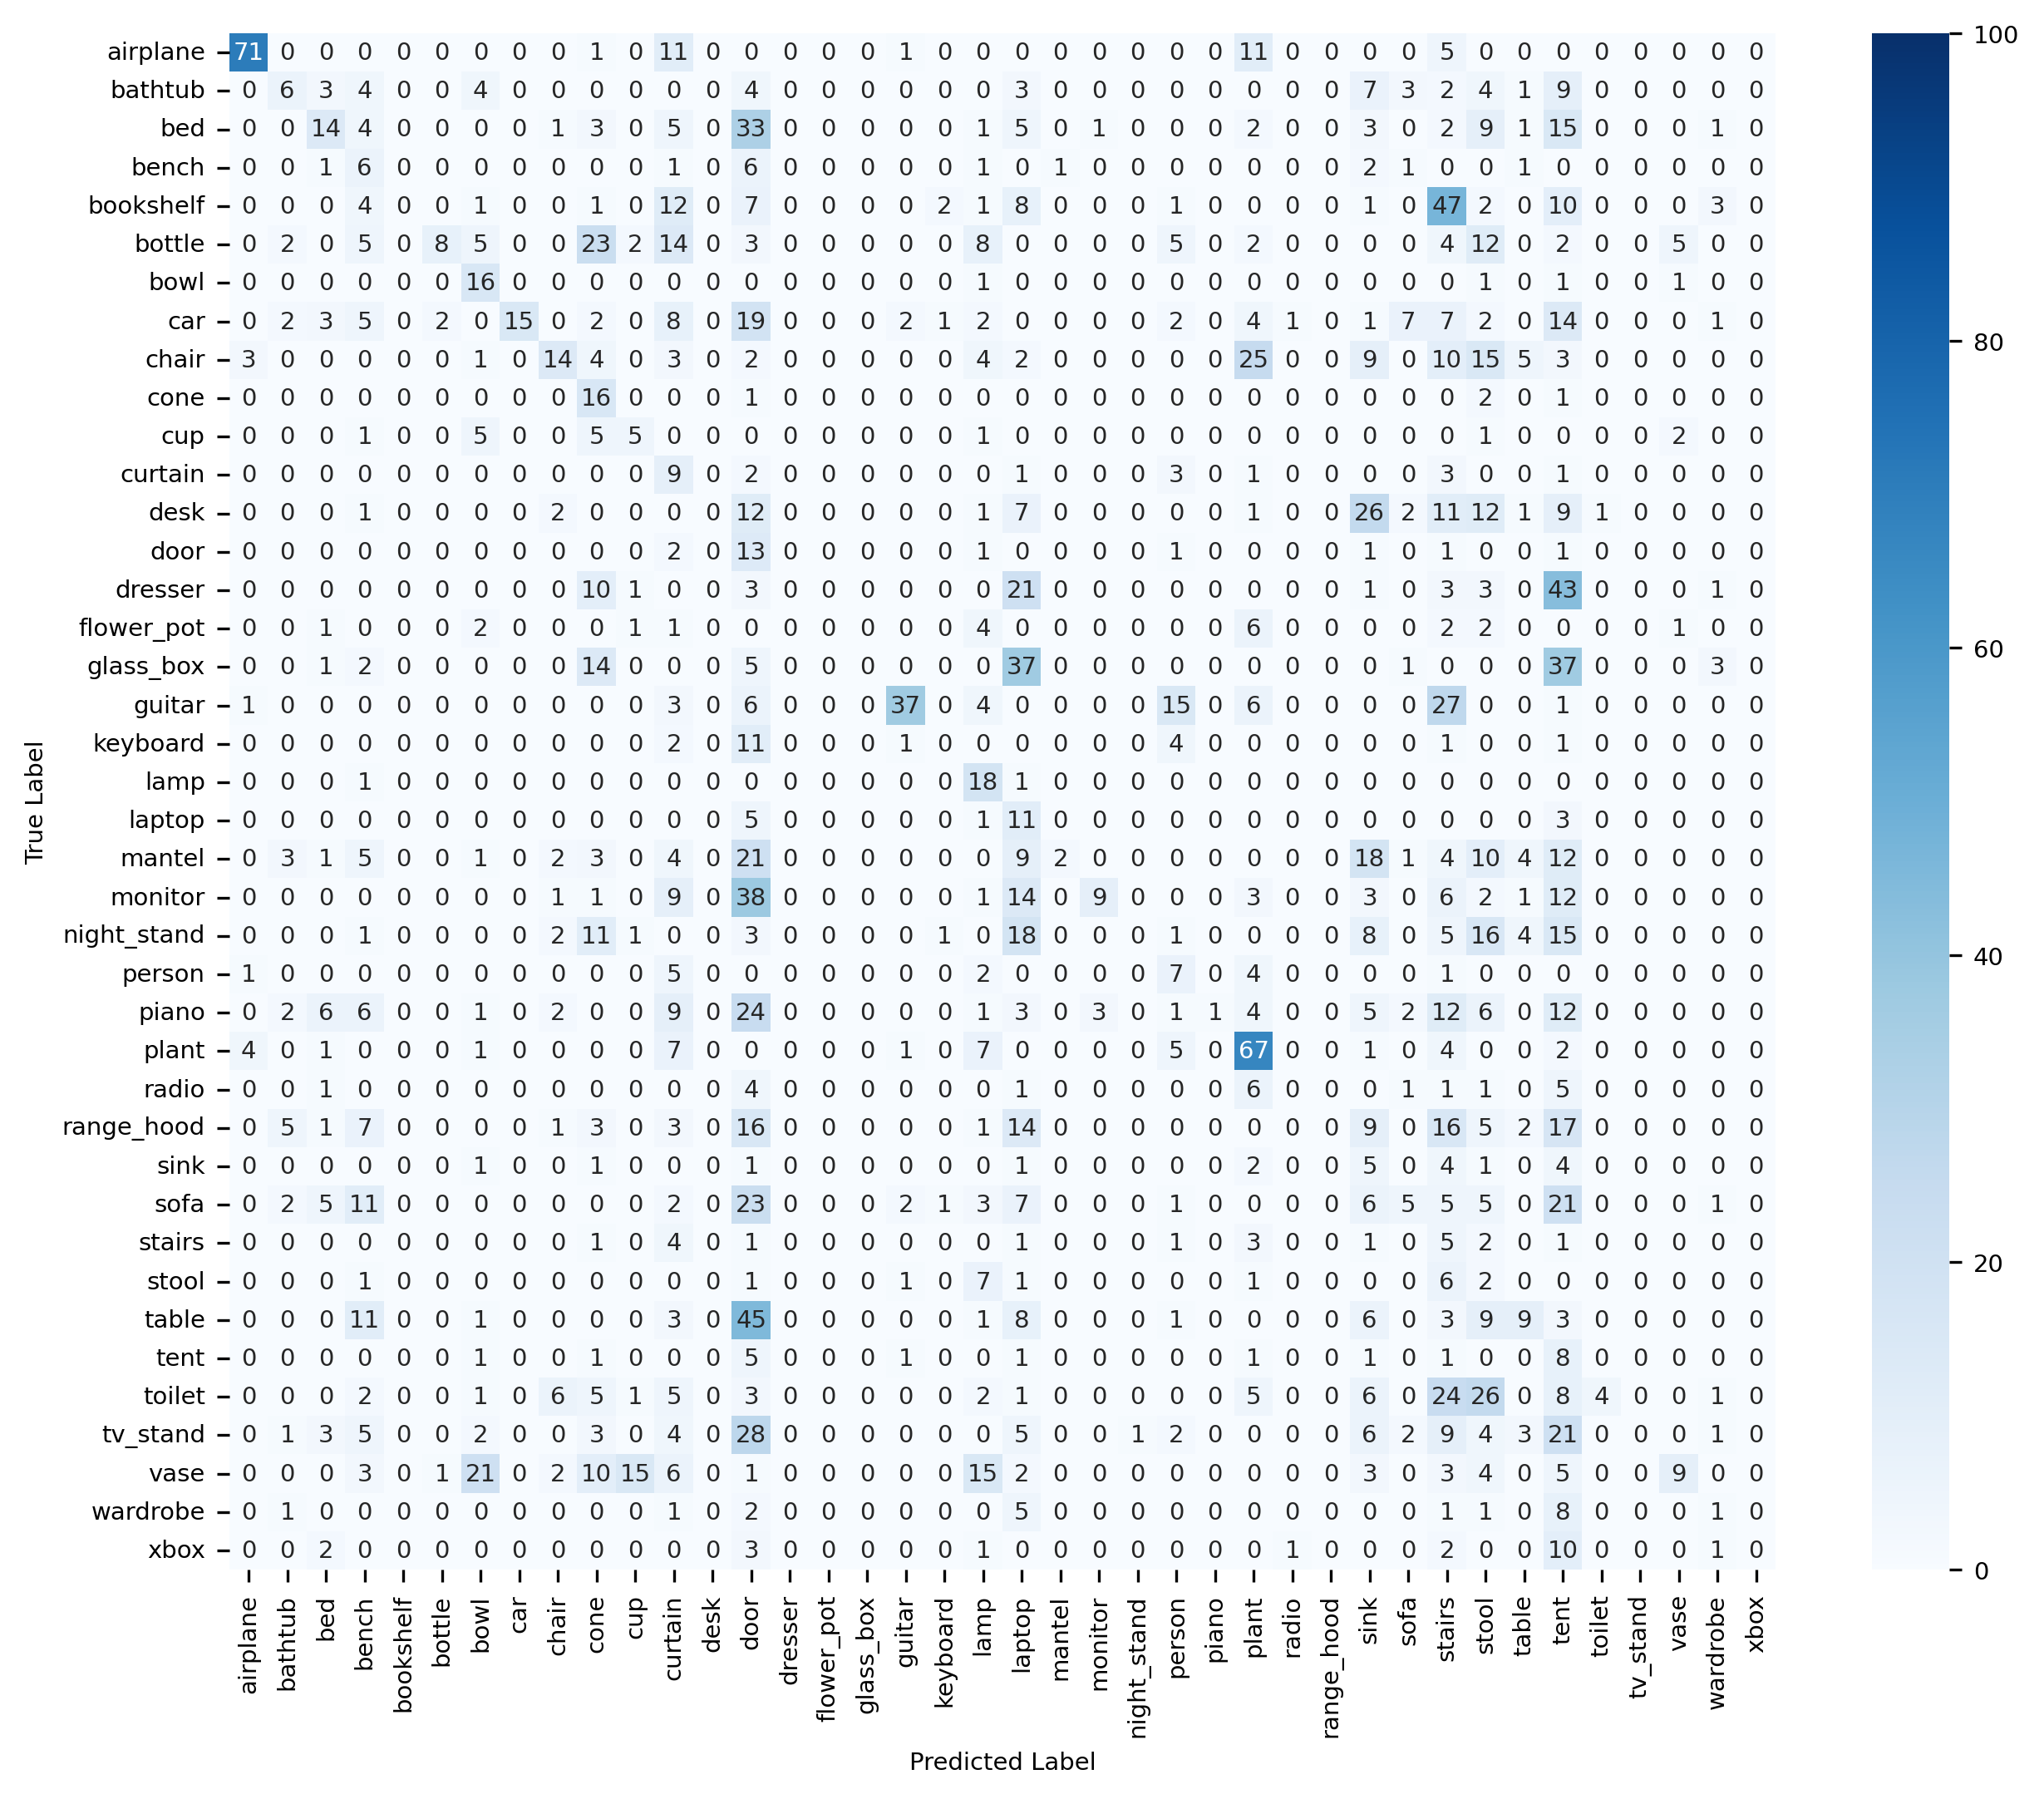

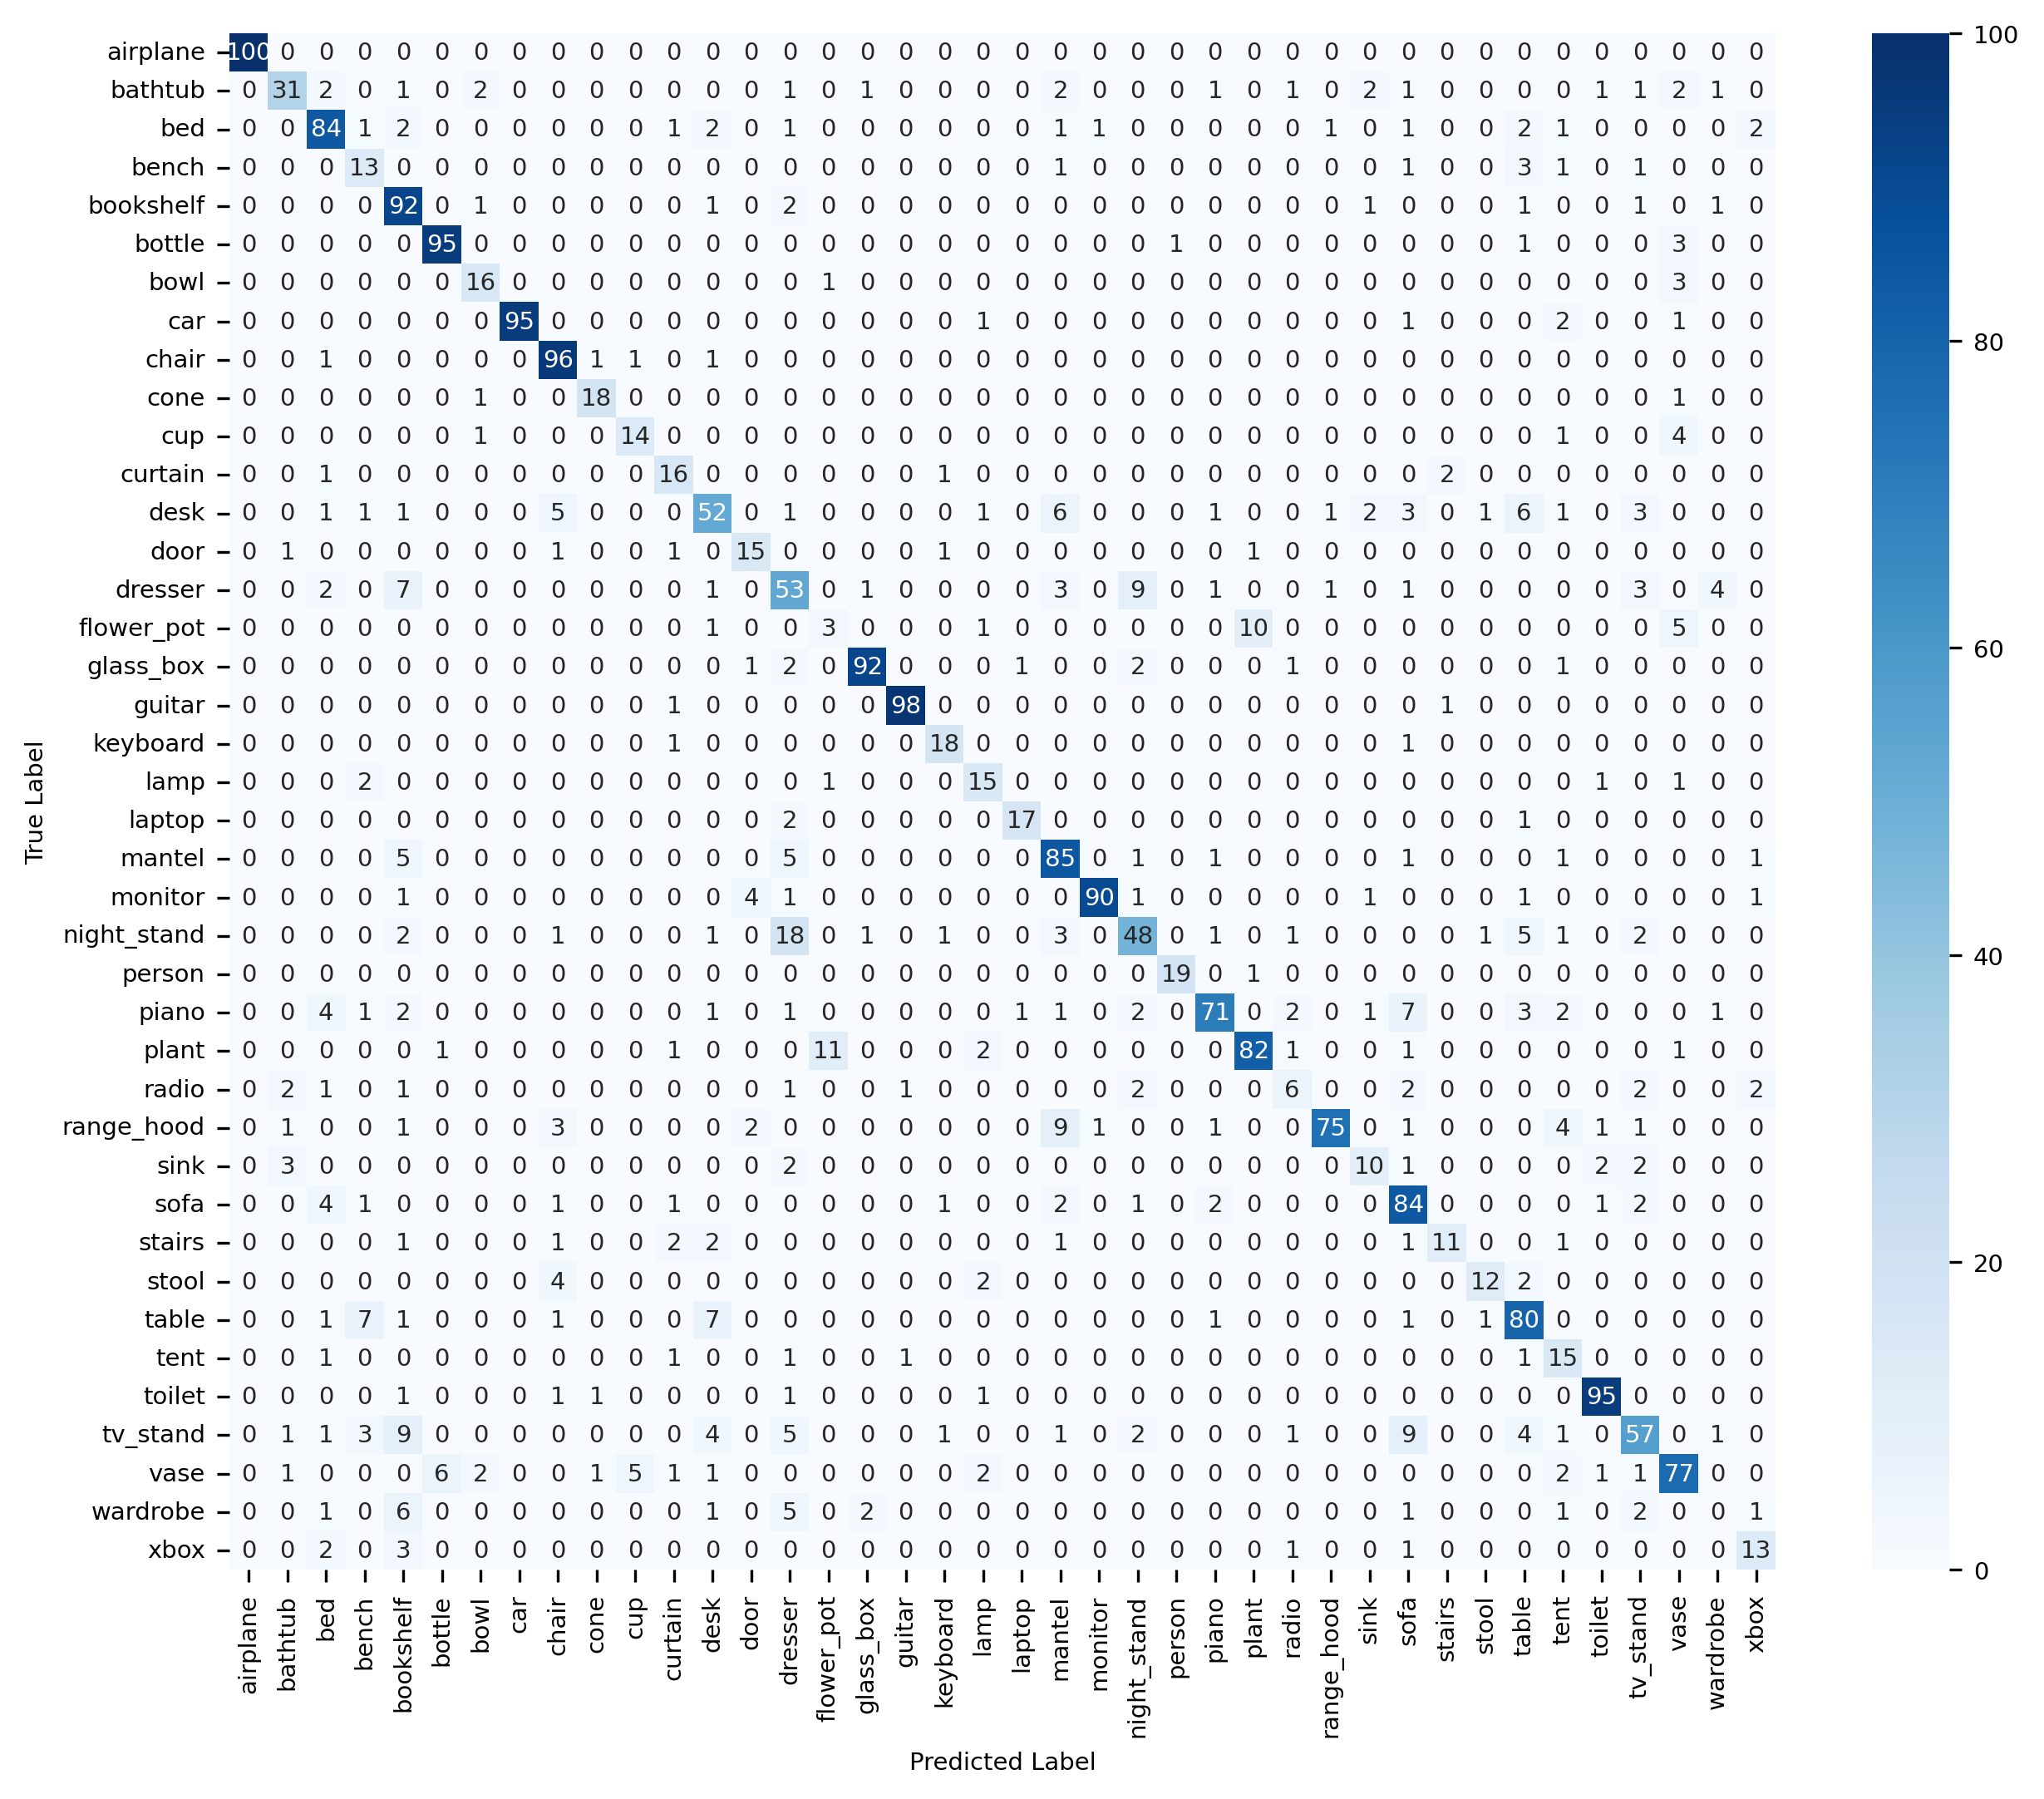

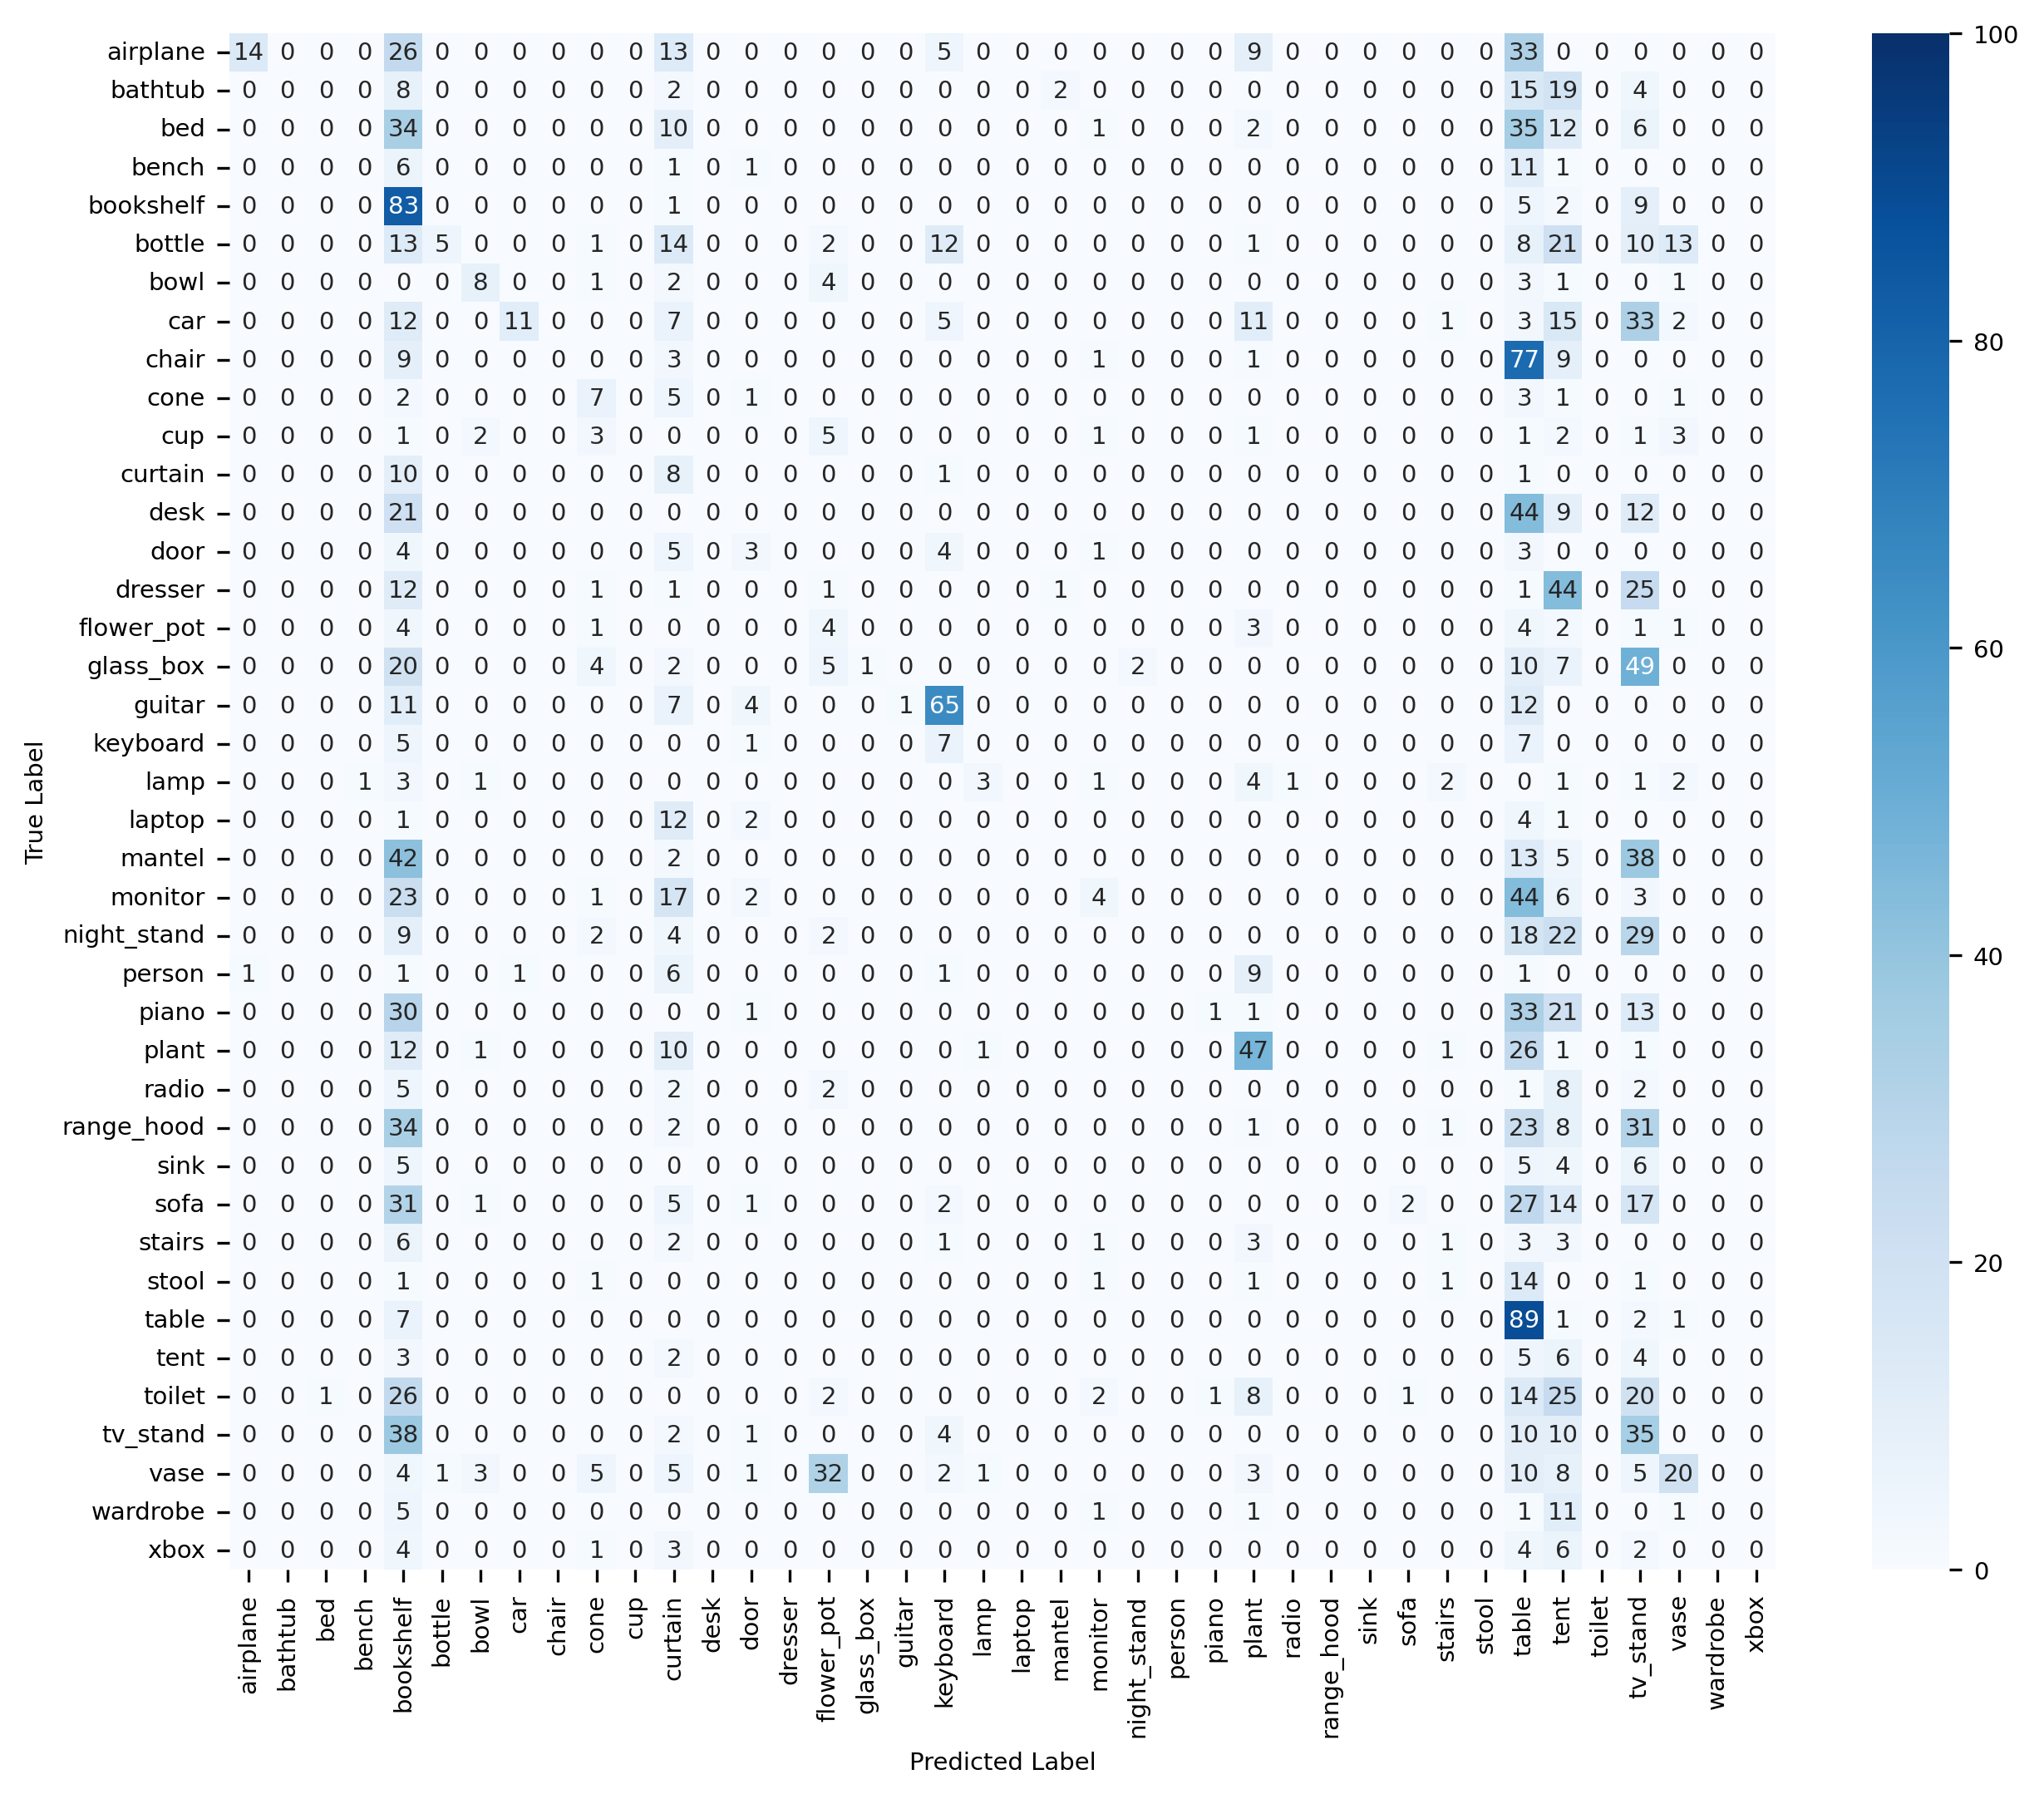

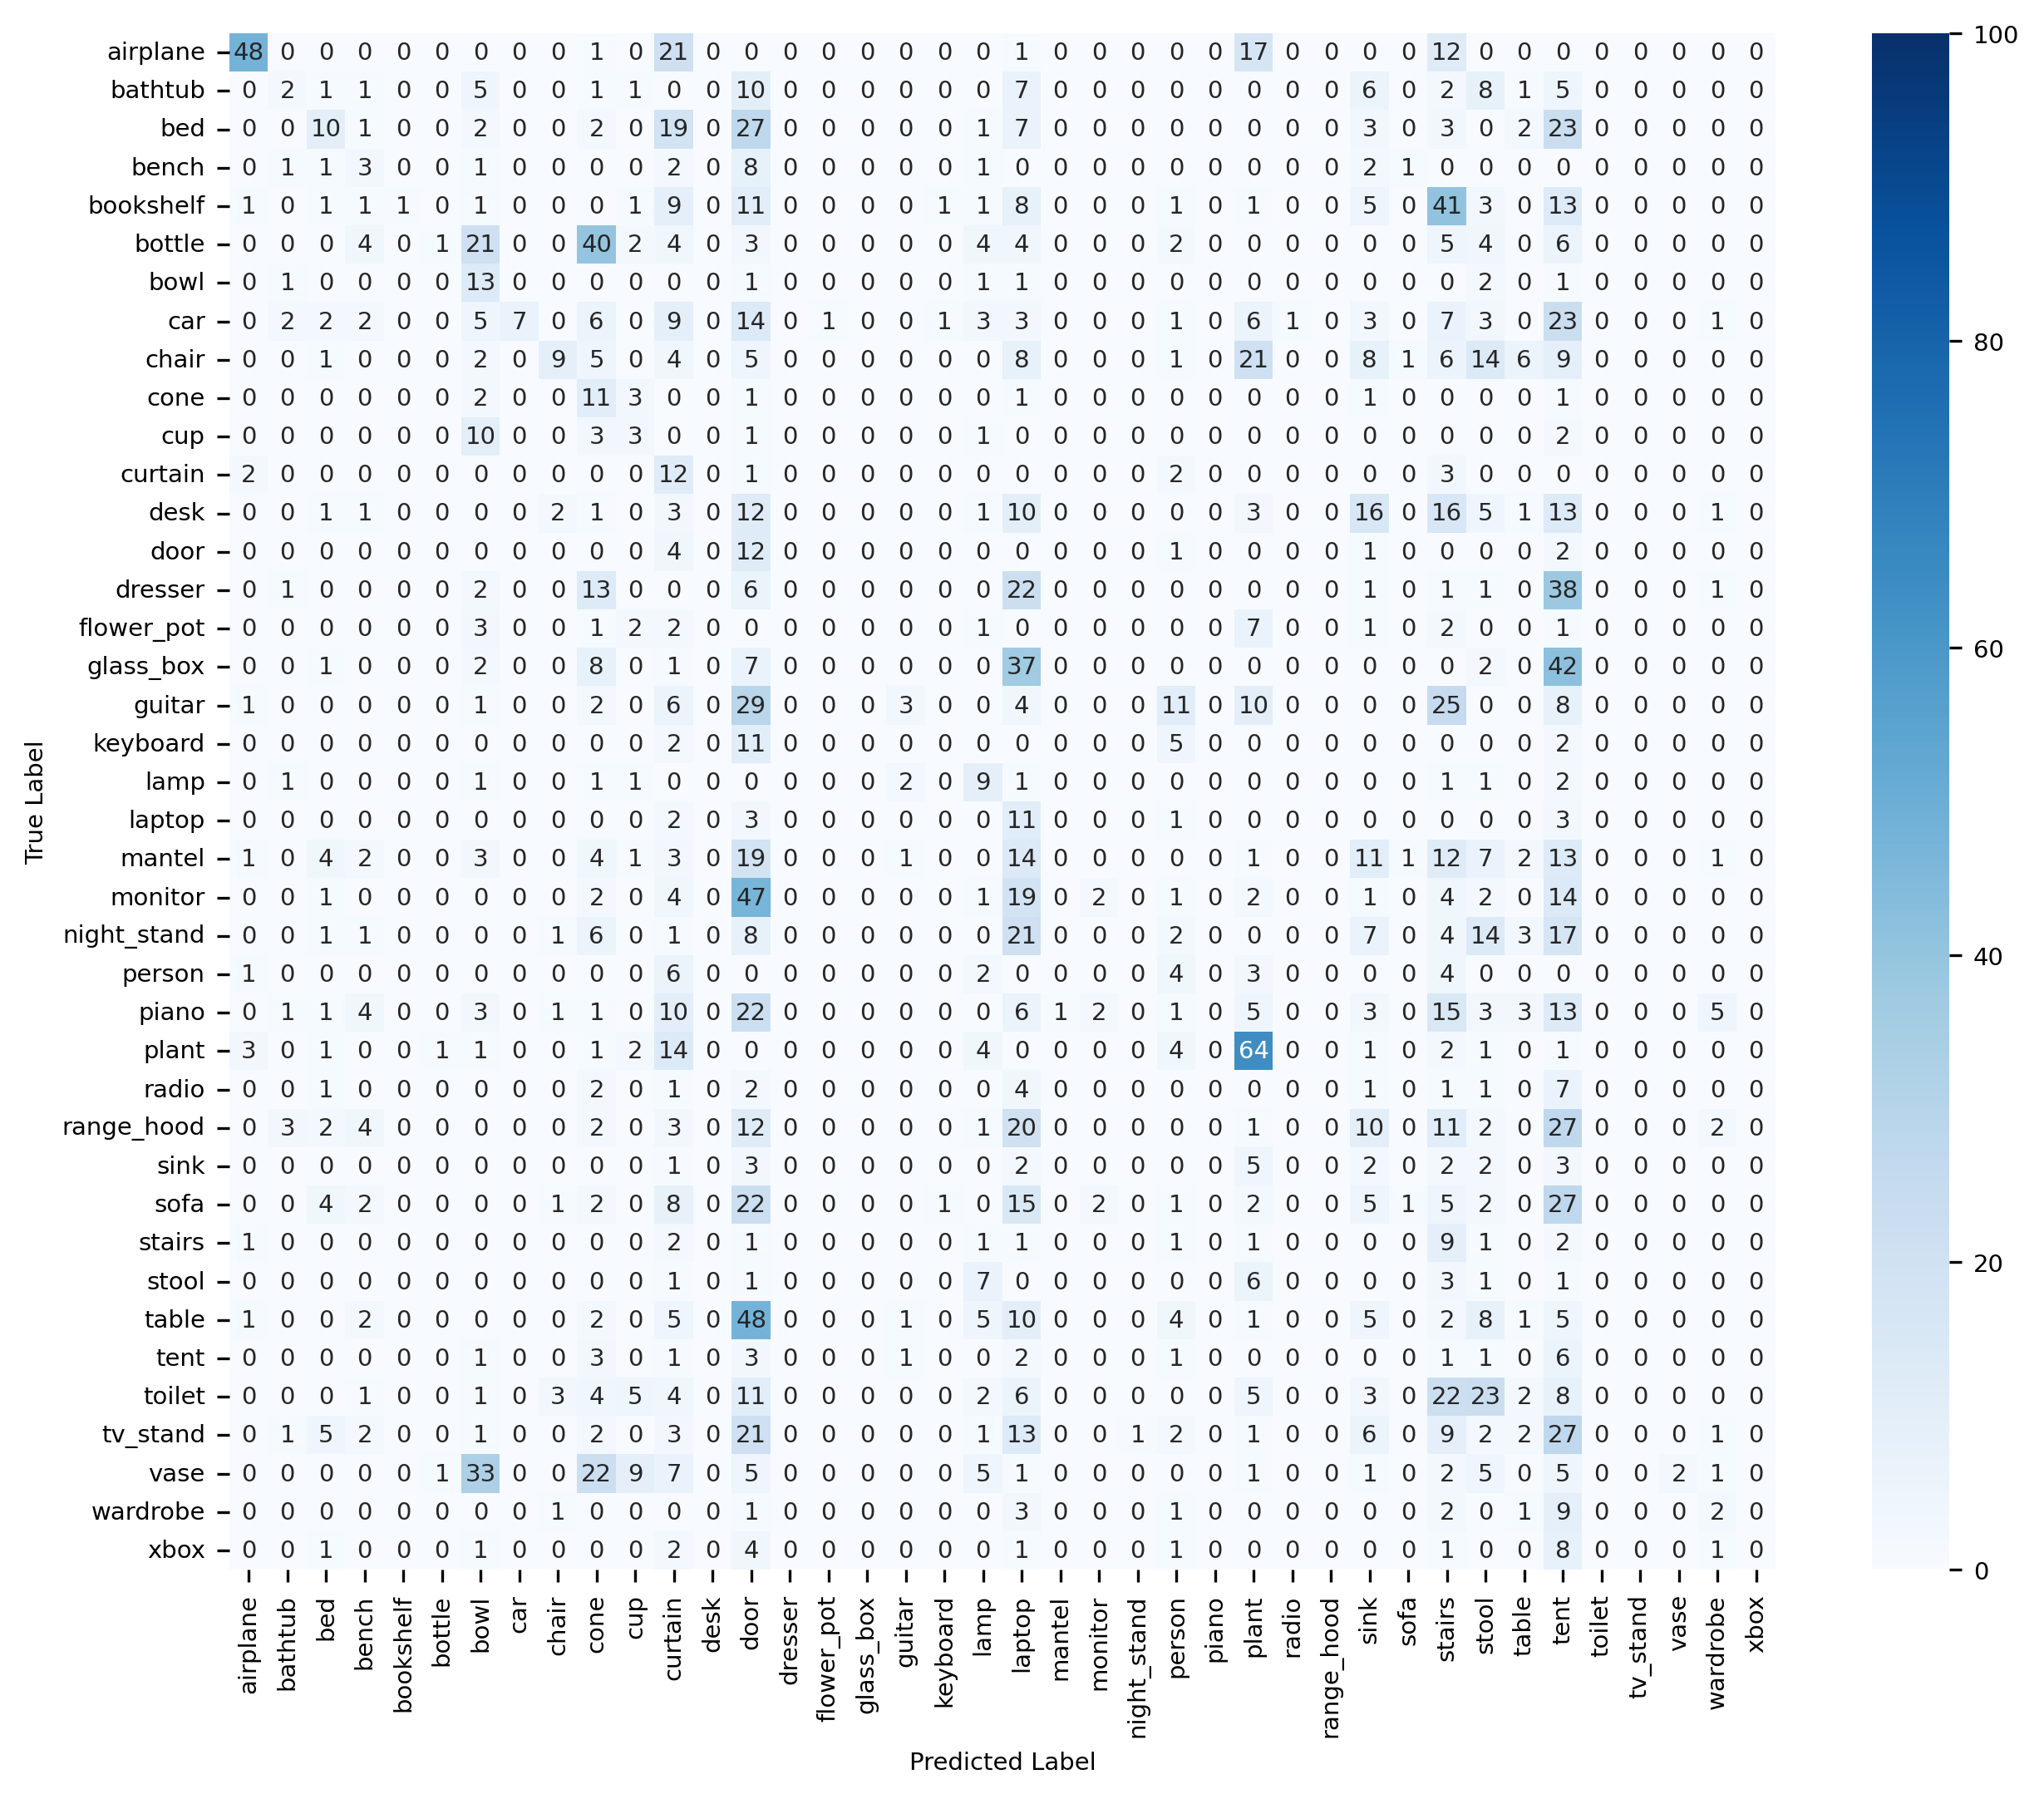

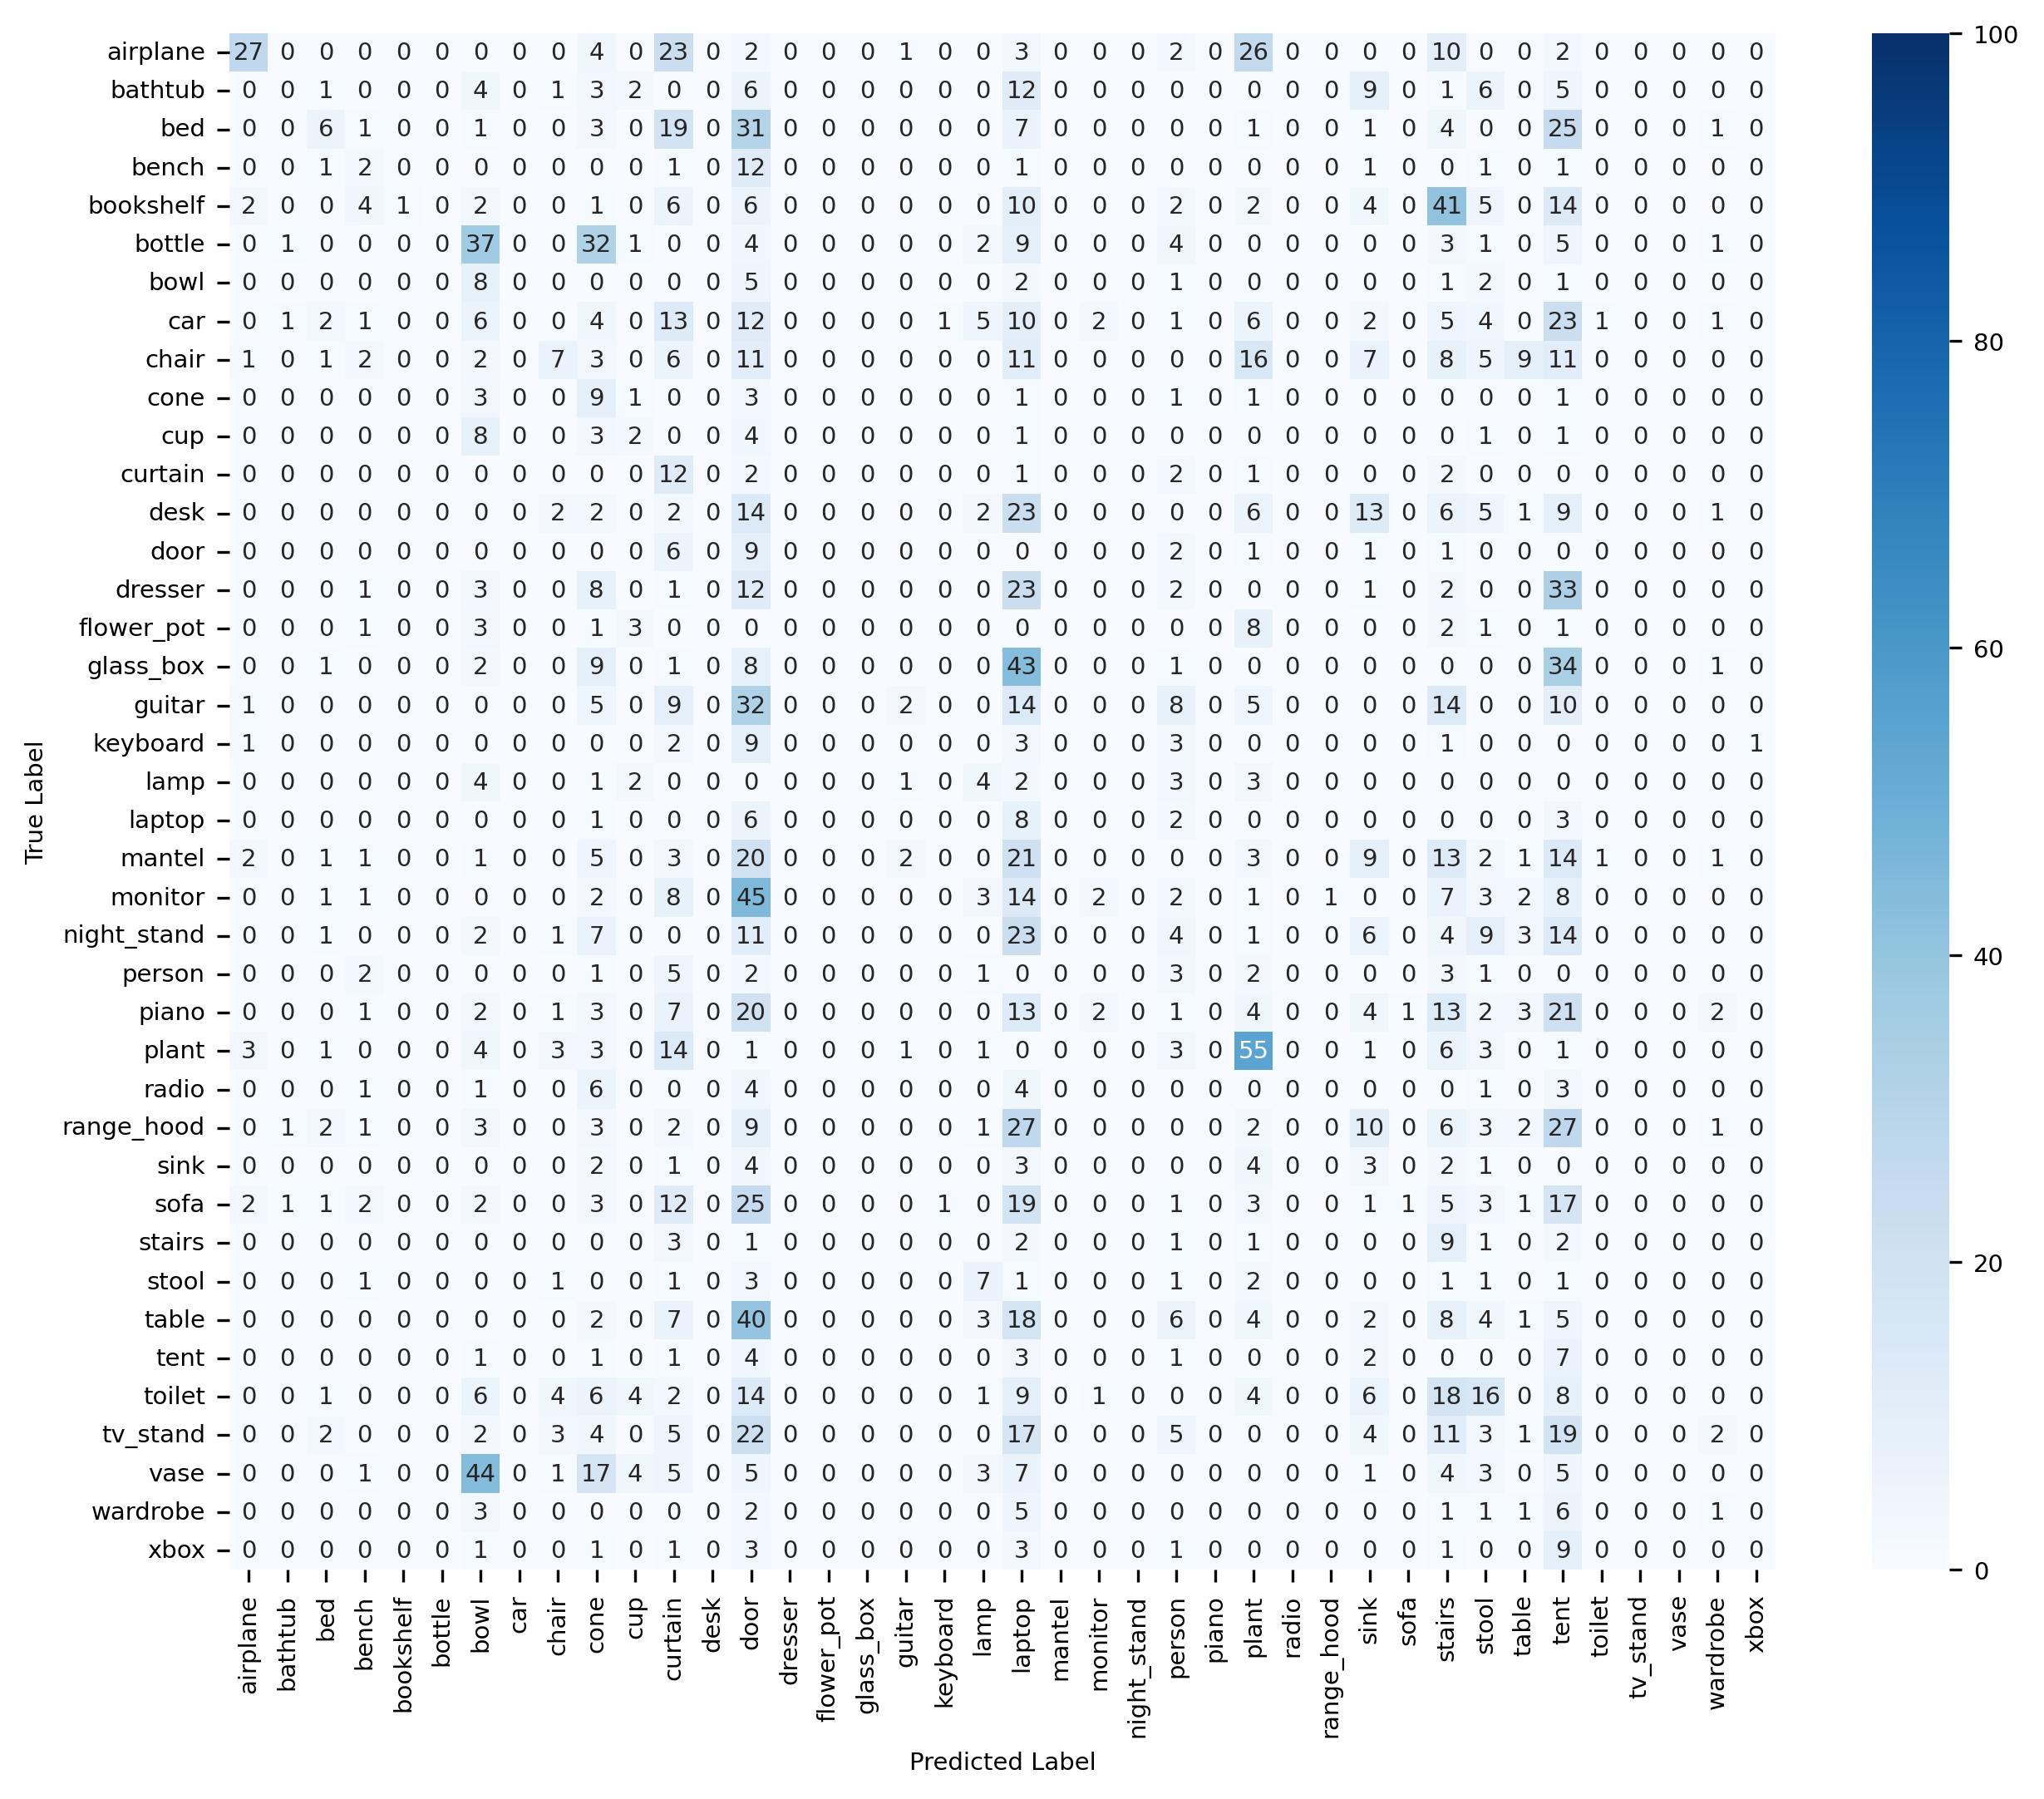

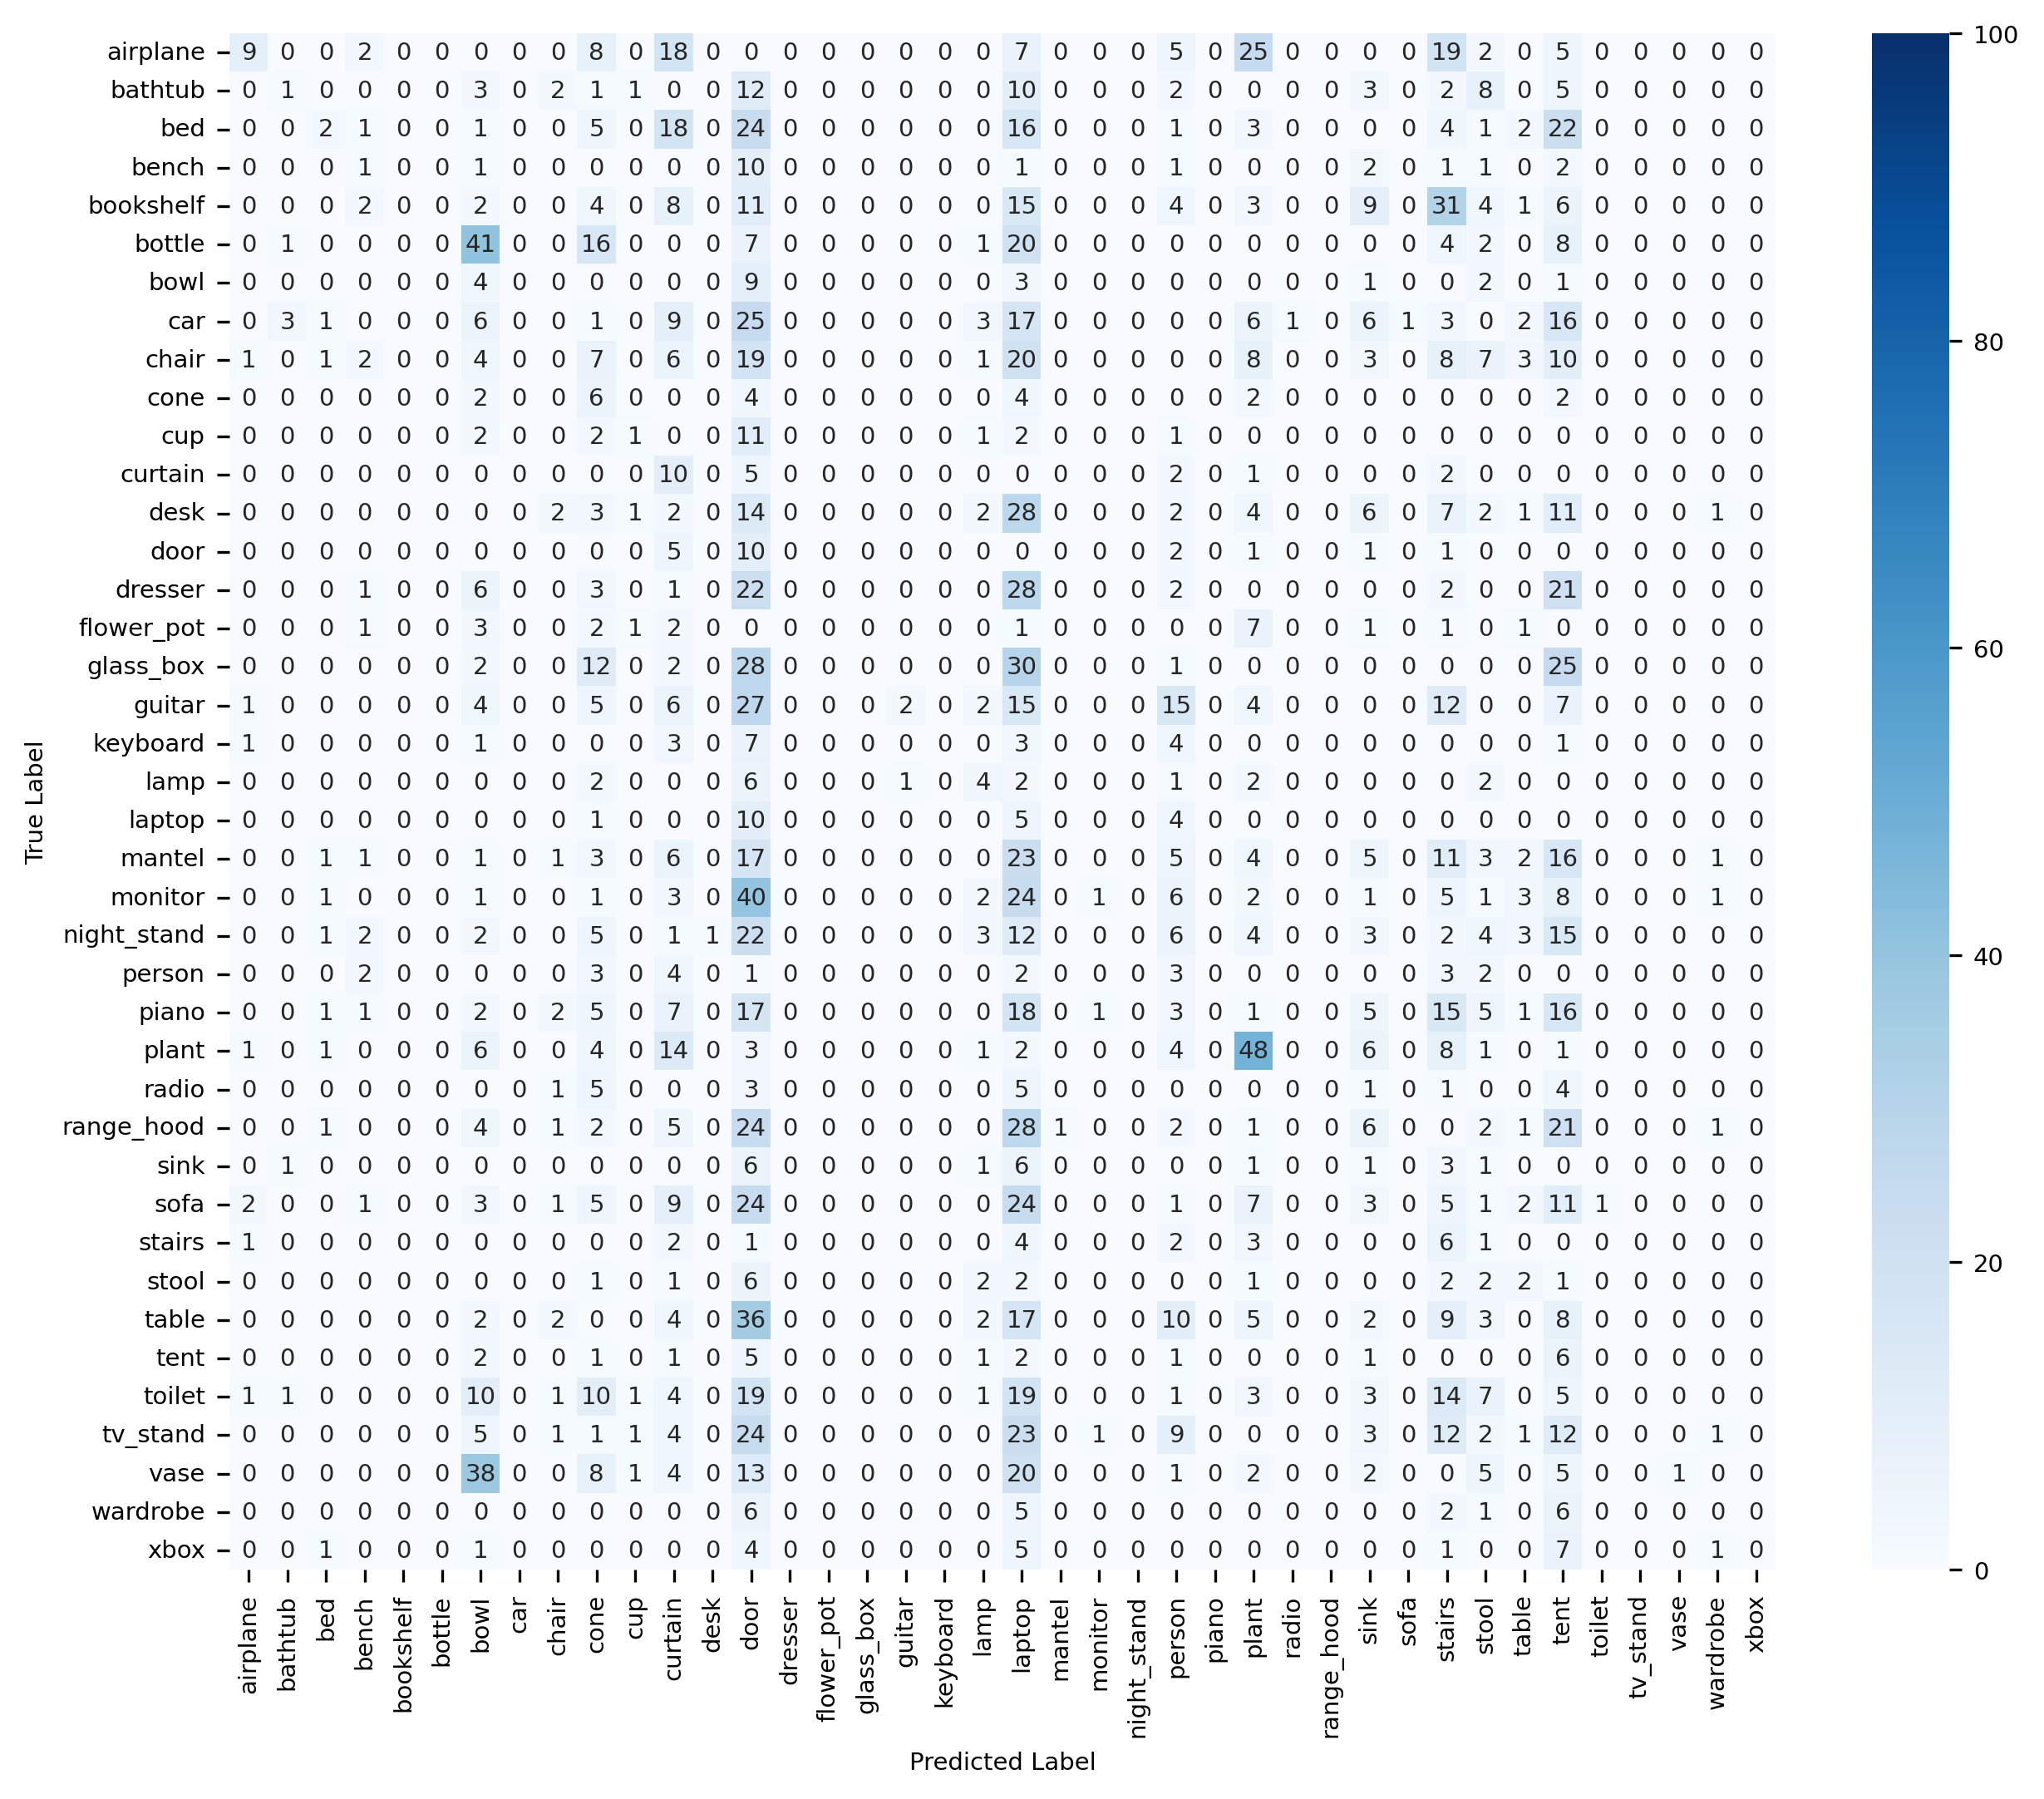

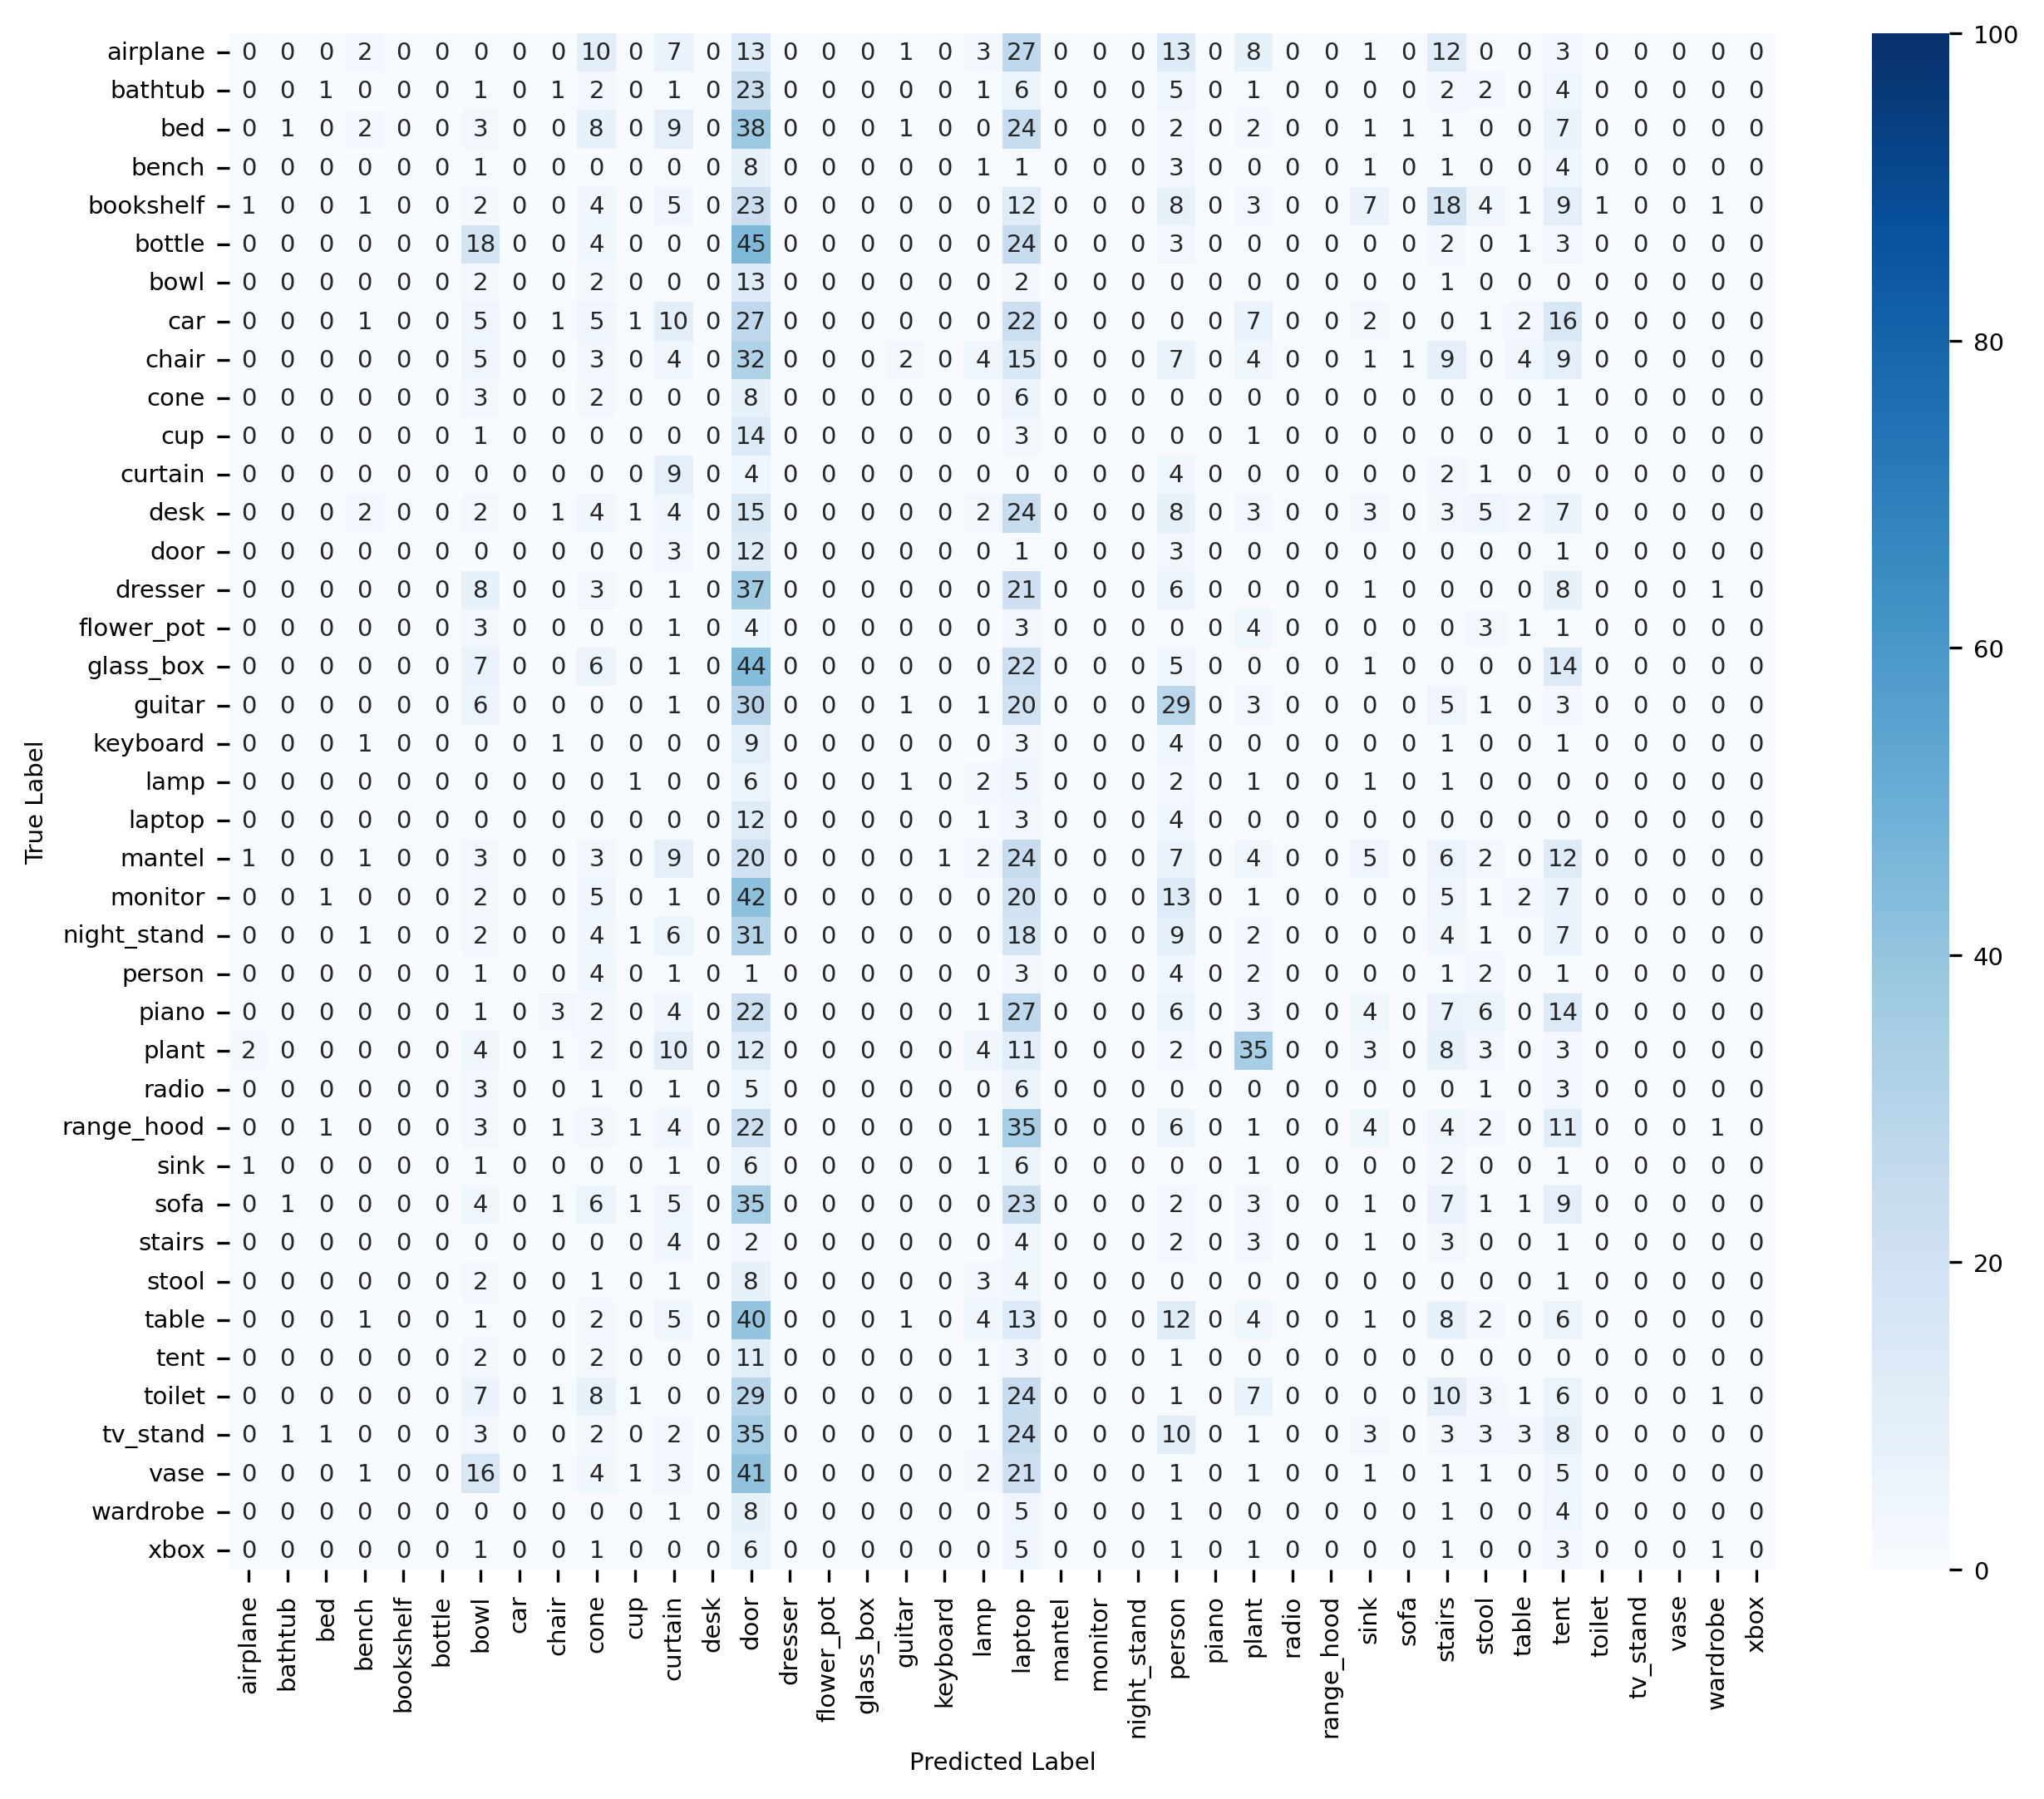

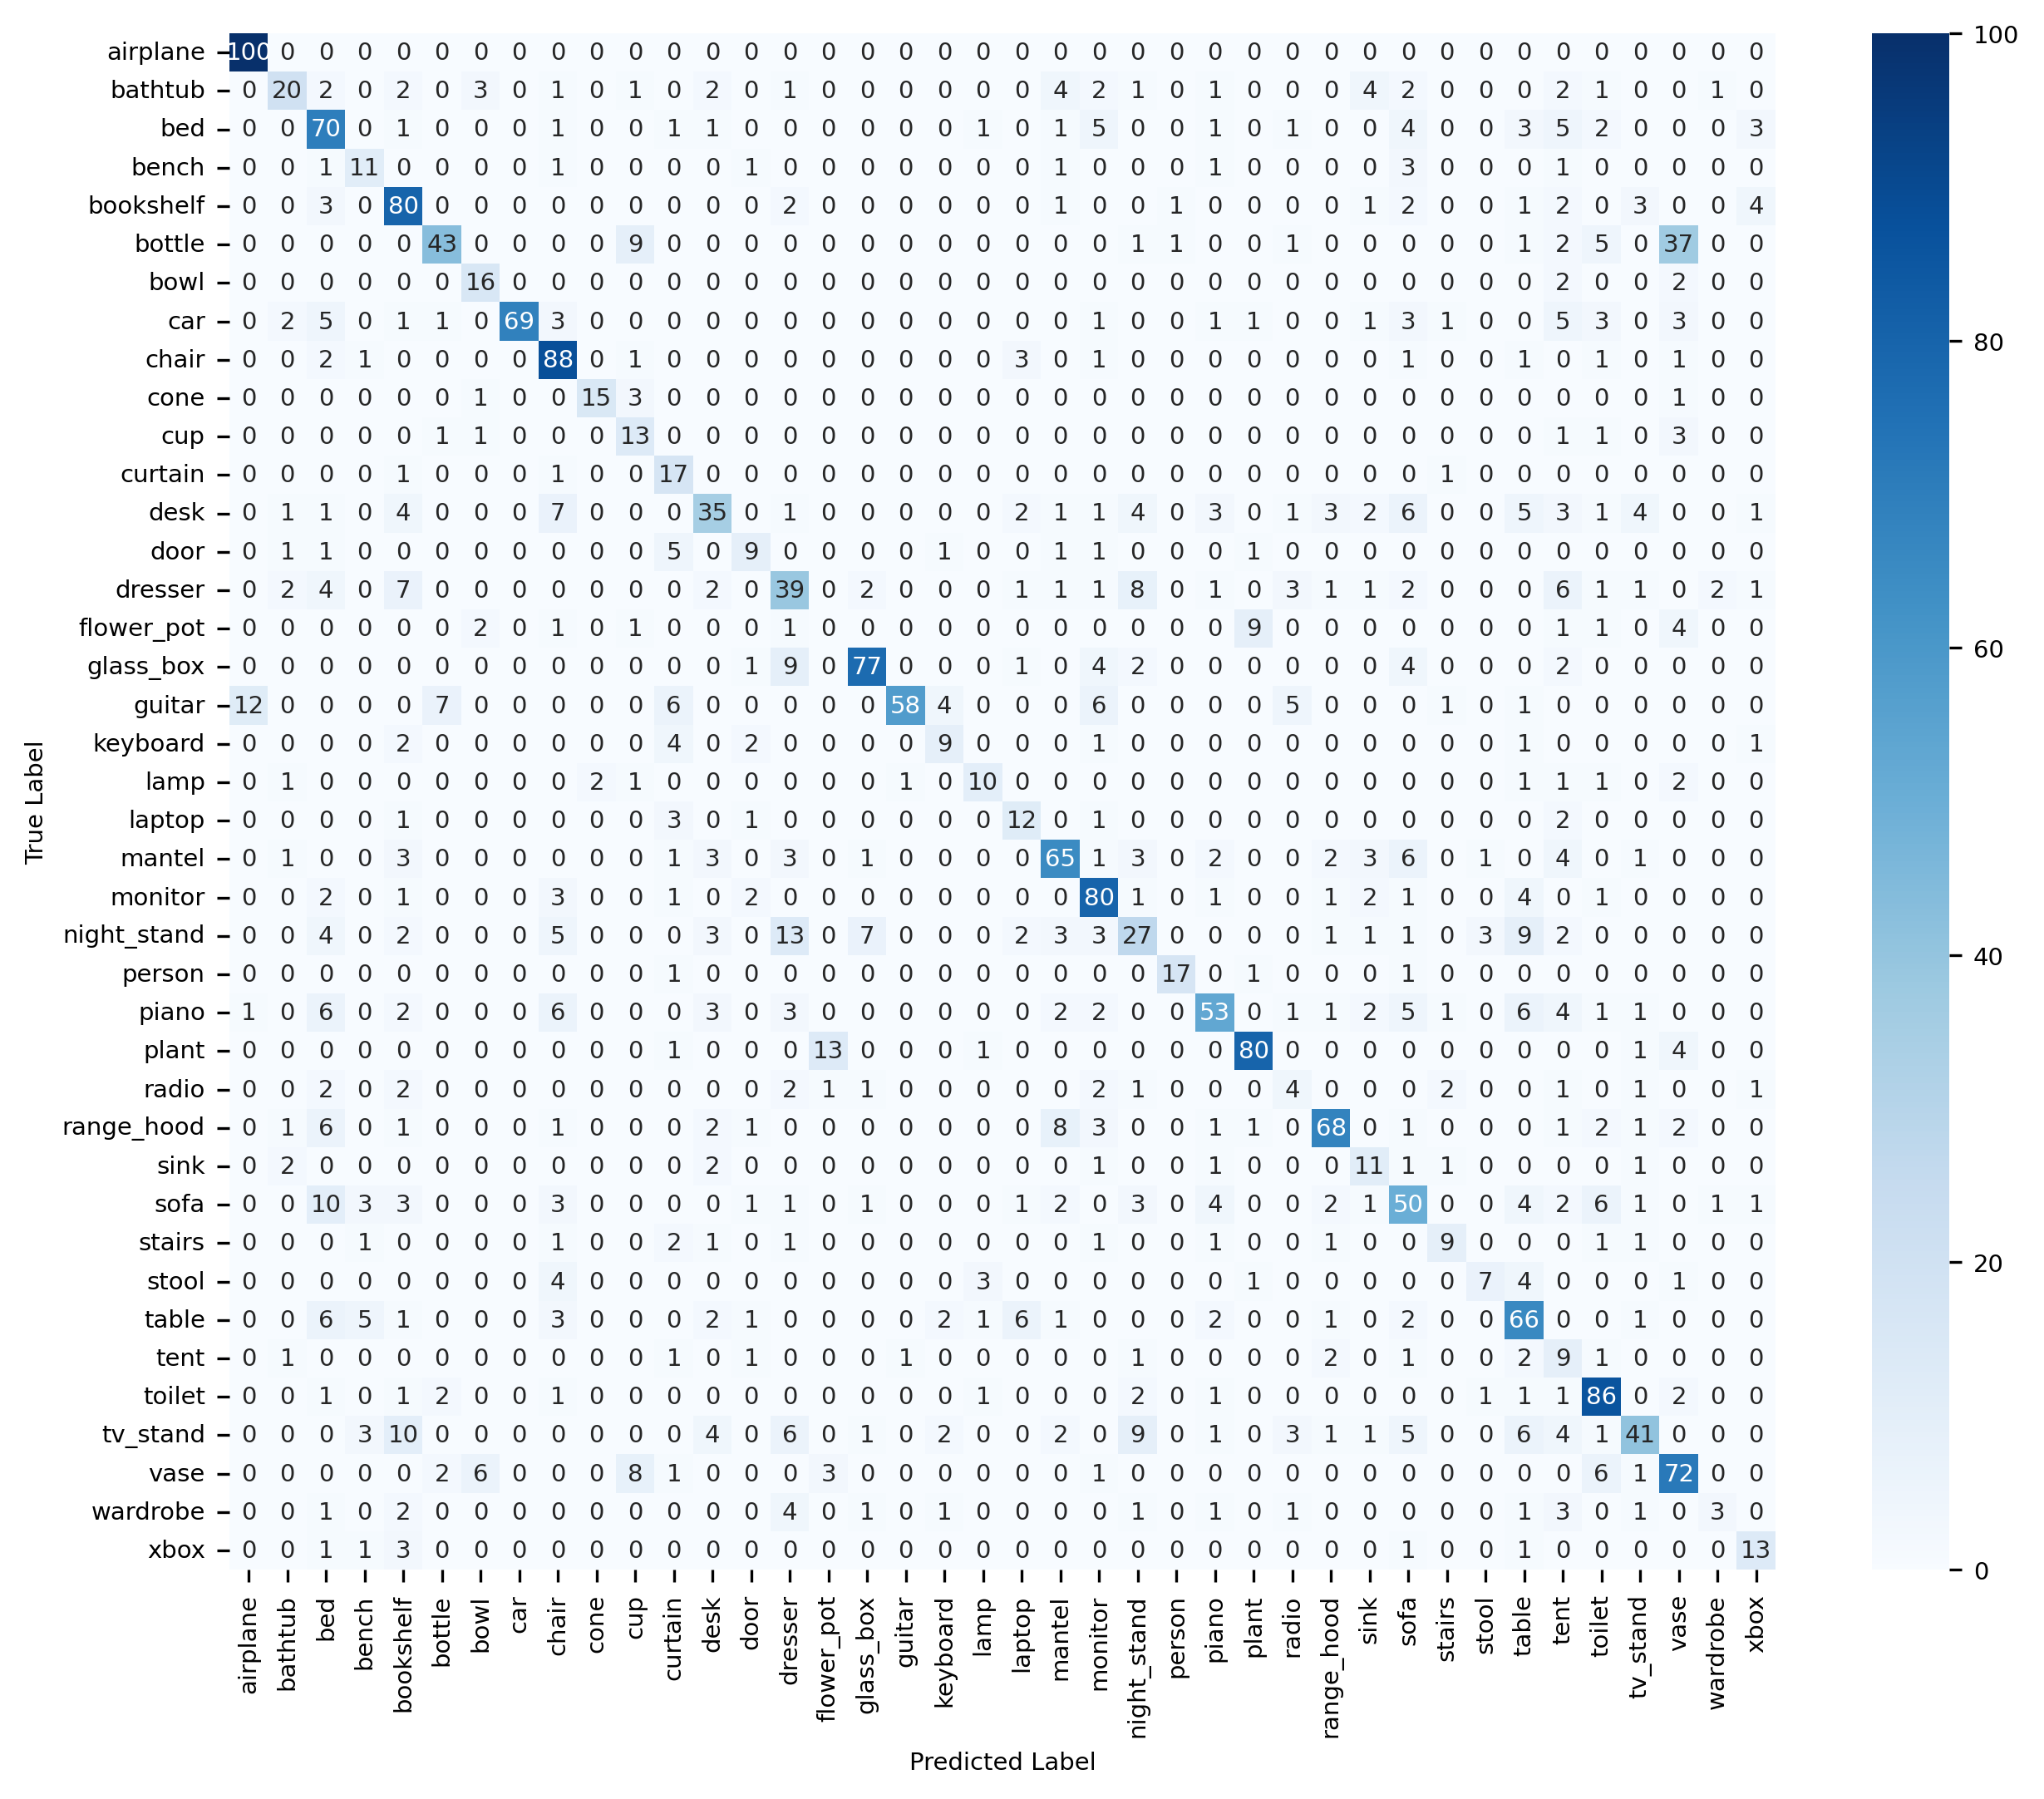

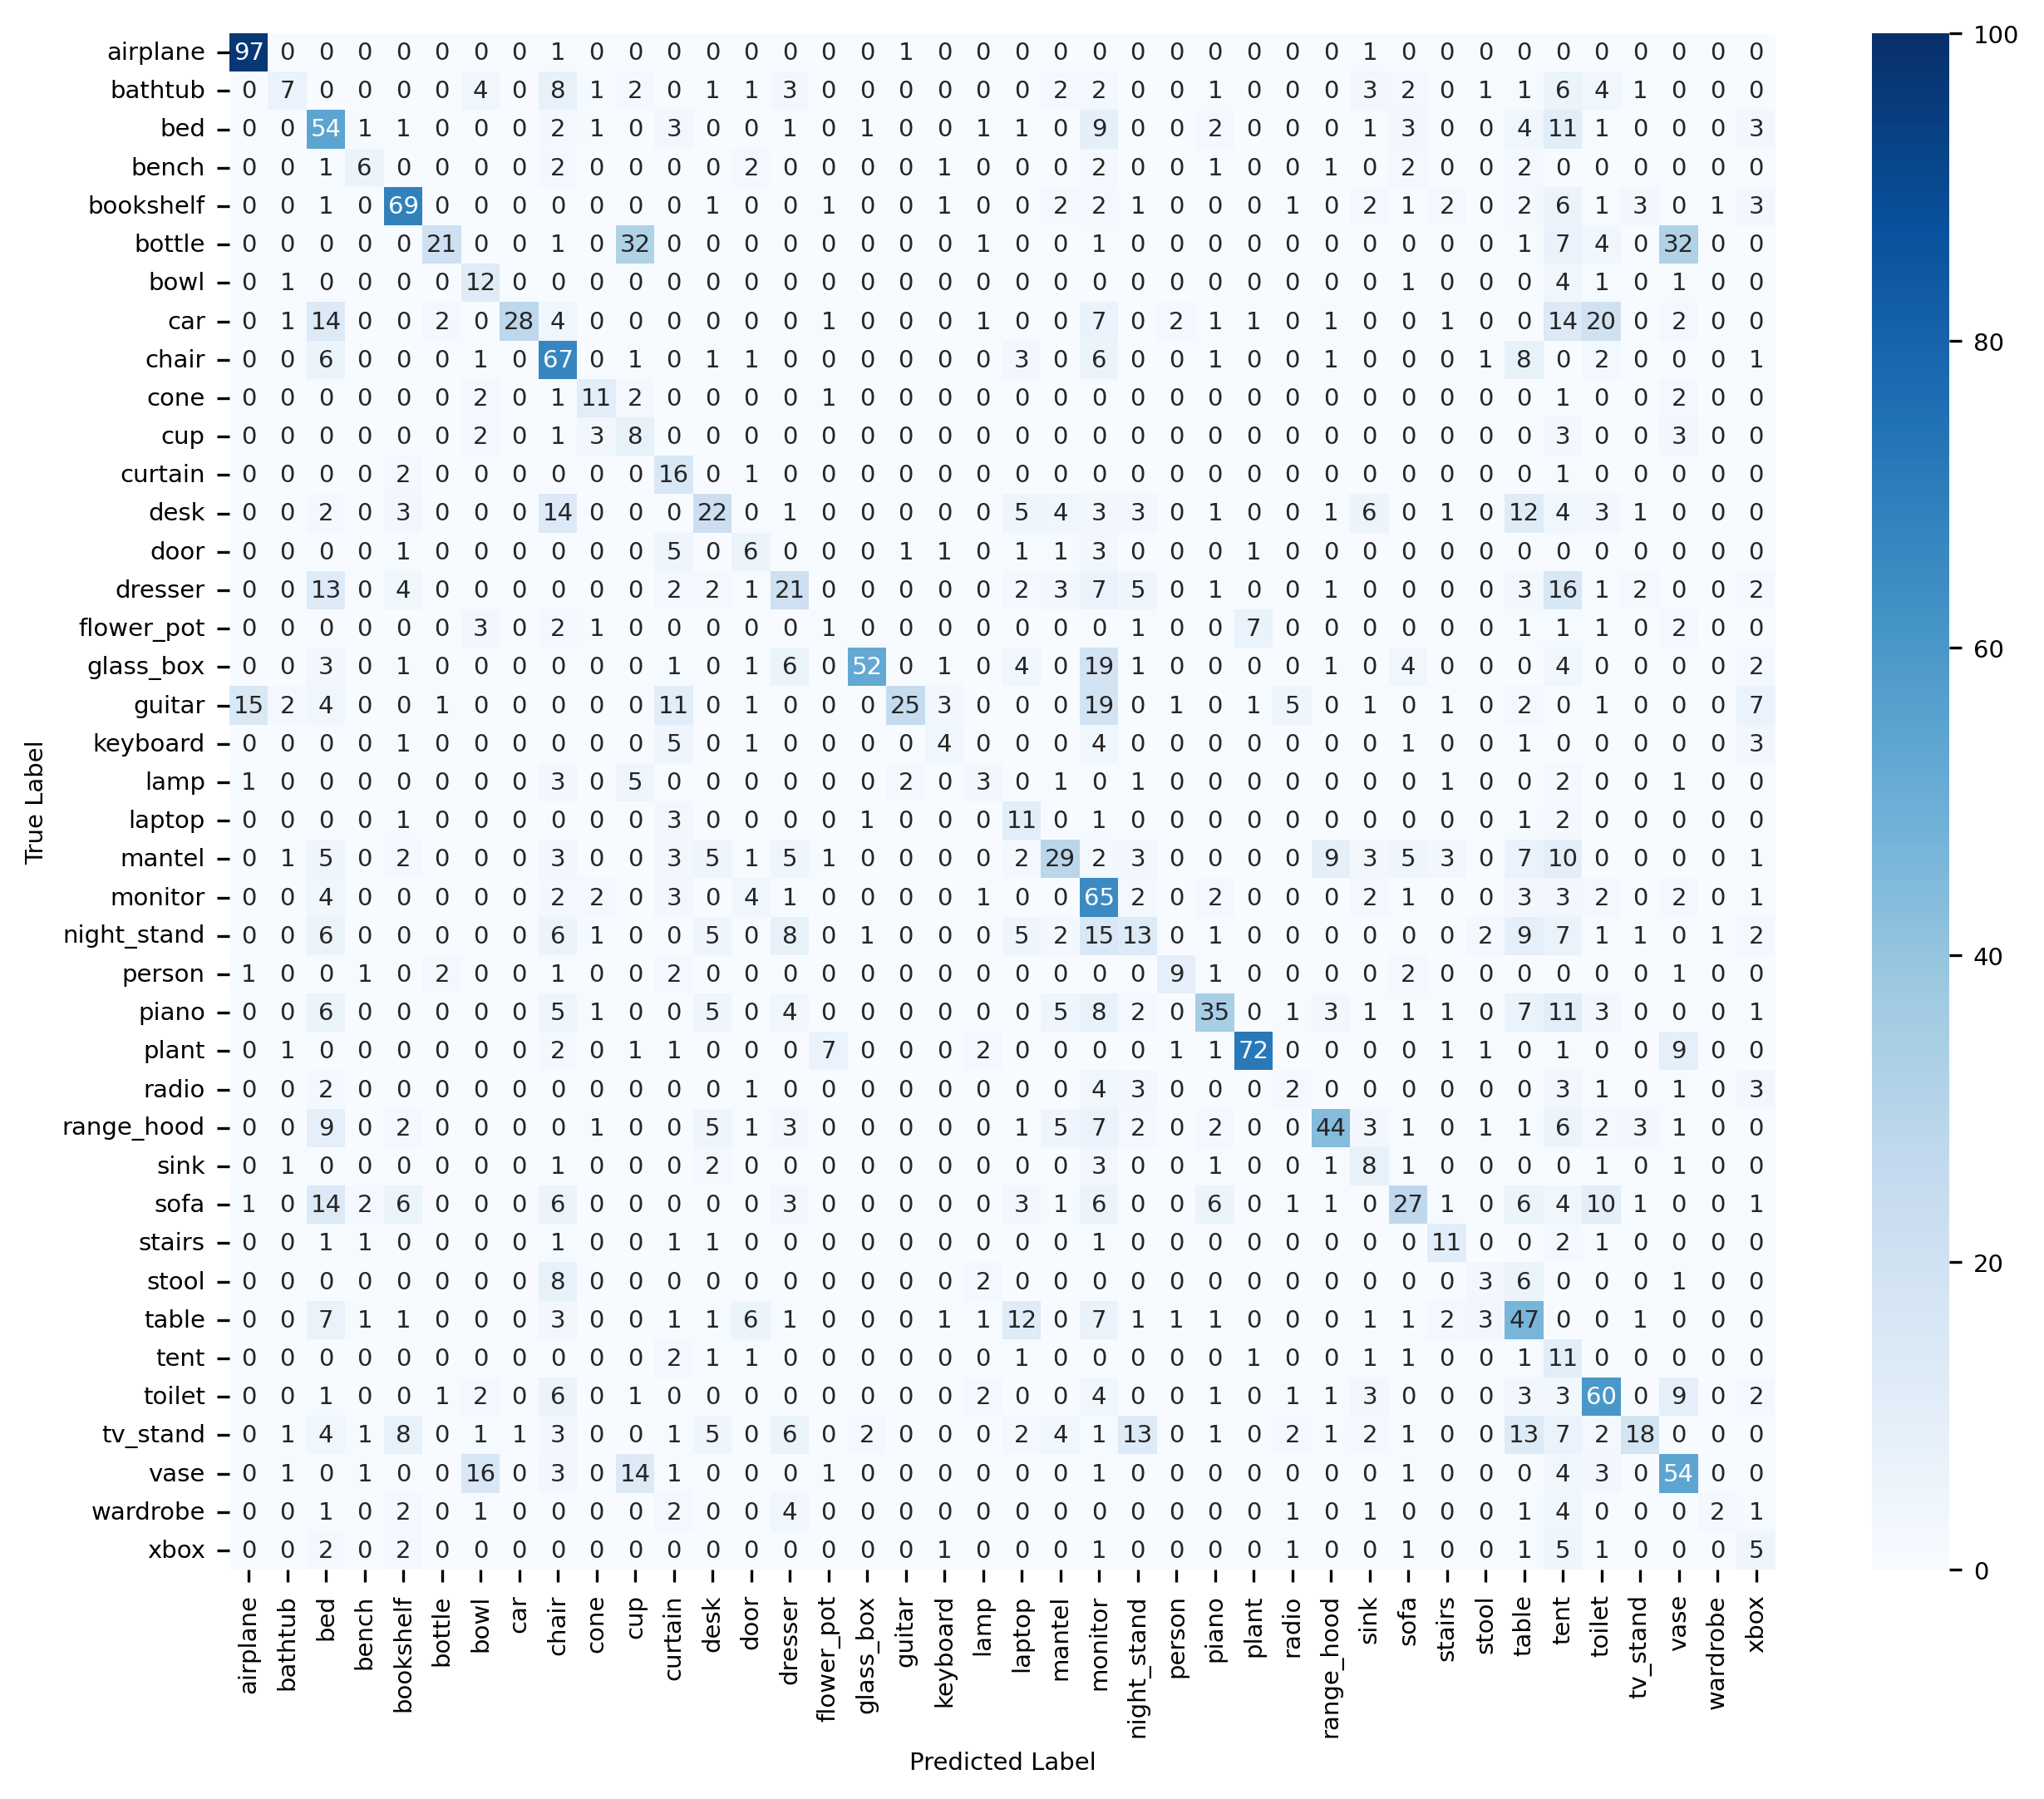

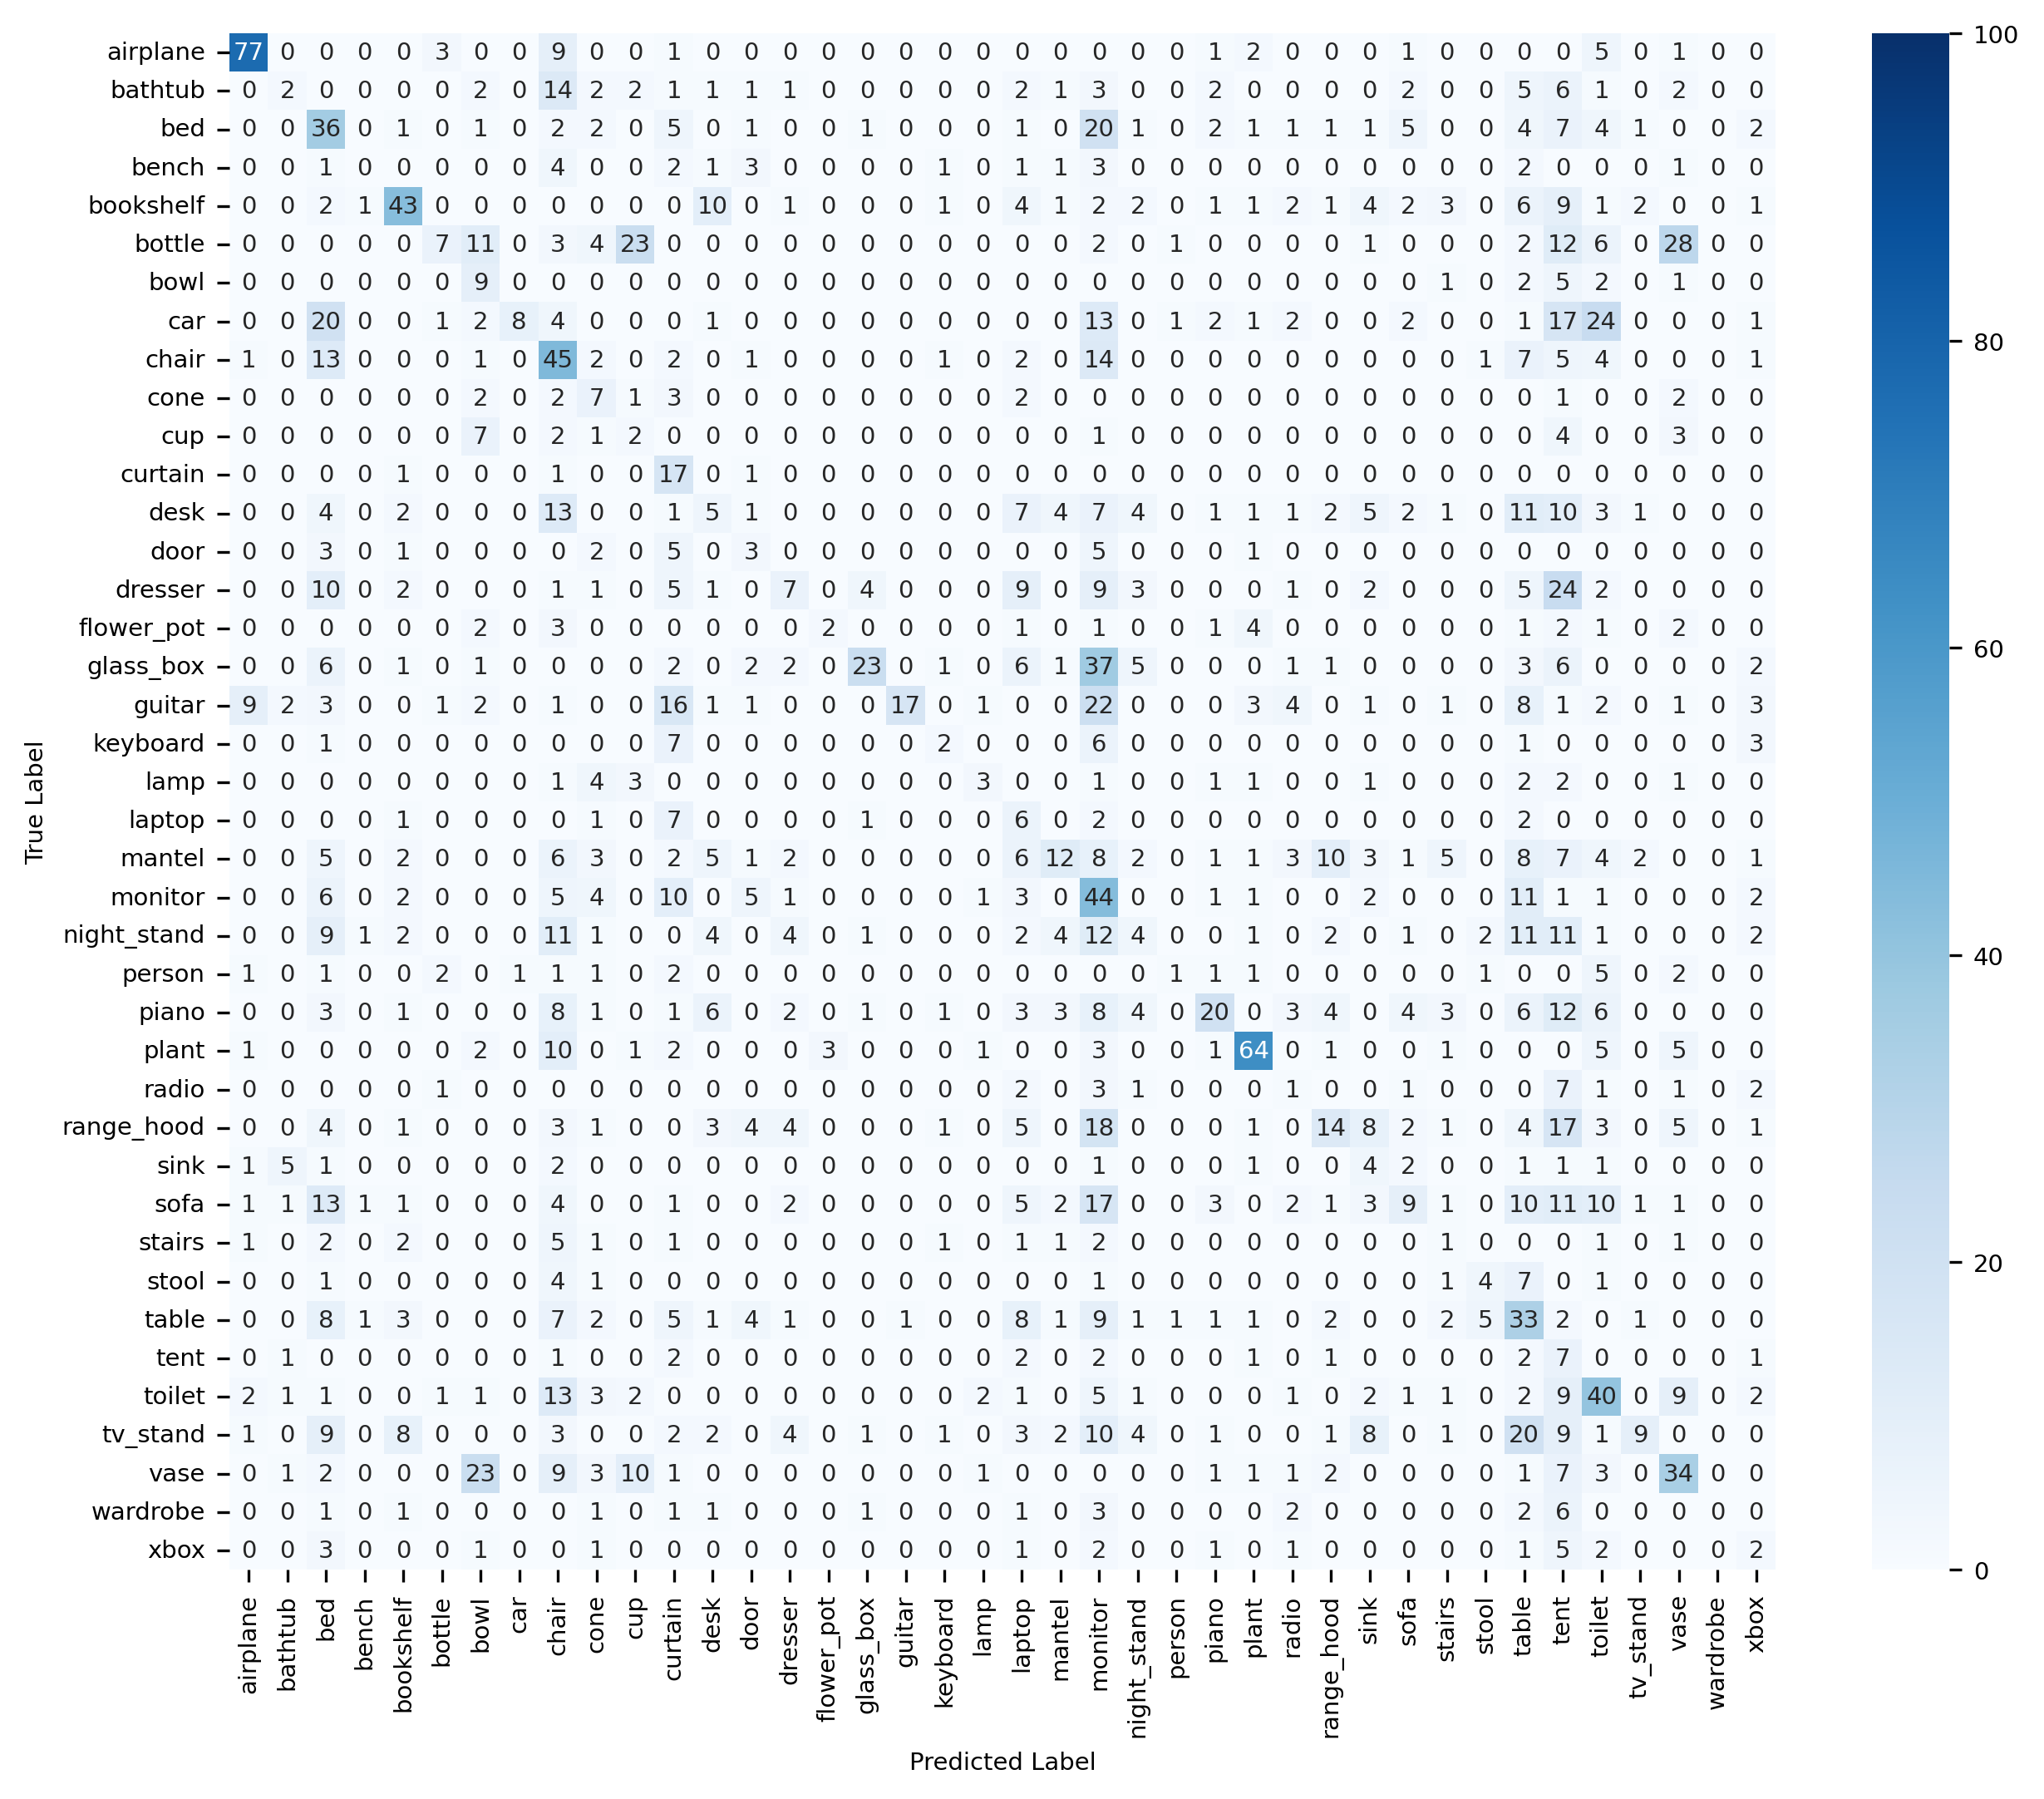

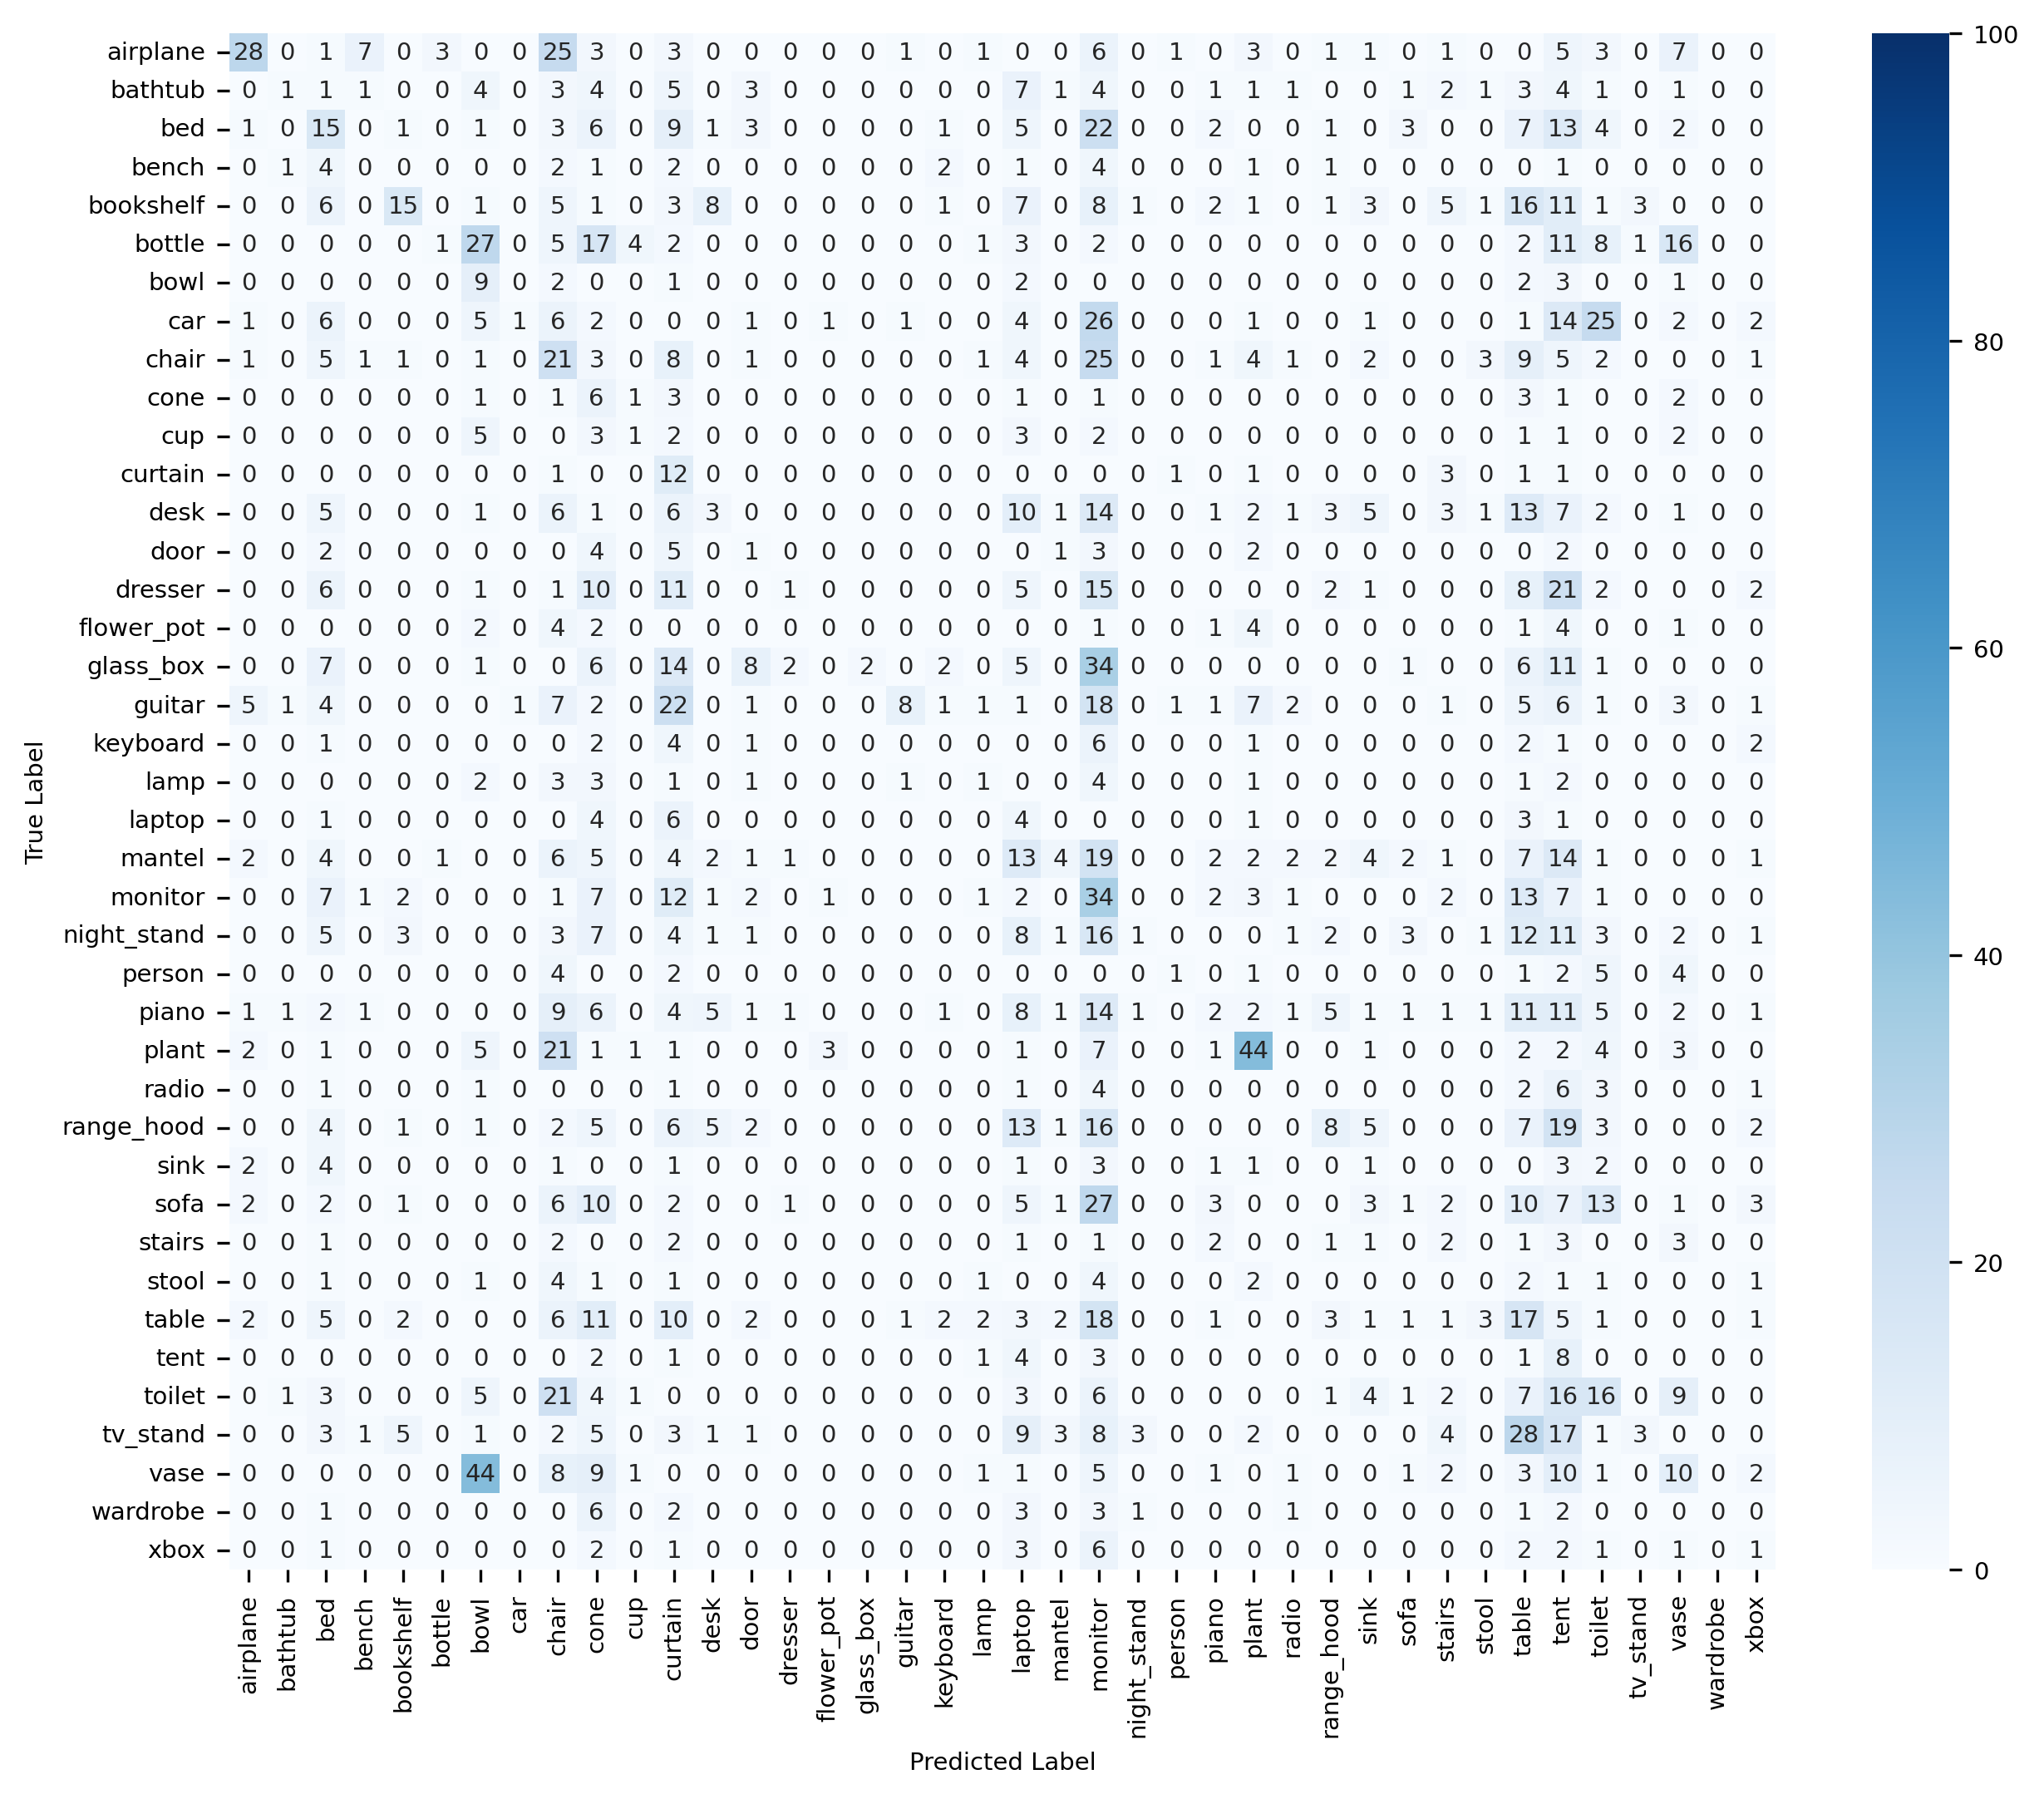

In [22]:
def make_confusion_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(10, 8), dpi=300)
    plt.rcParams.update({'font.size': 7})
    ax = sns.heatmap(
        data=cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names.values(),
        yticklabels=class_names.values(),
        ax=ax,
        vmax=100,
        vmin=0
      )
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

    return fig, ax


# Make the confusion matrix for all results, save to output folder
for col in tqdm(columns, desc='Drawing Confusion Matrices'):
  model, test = col.split('_')
  y_true = result_df['y_true']
  y_pred = result_df[col]
  fig, ax = make_confusion_matrix(y_true, y_pred, class_names)
  ax.set_title('')
  fig.savefig(os.path.join(results_dir, f'v2_cm_{model}_trained_{test}_tested.png'), bbox_inches='tight')

Drawing Confusion Matrices: 100%|██████████| 12/12 [00:04<00:00,  2.53it/s]


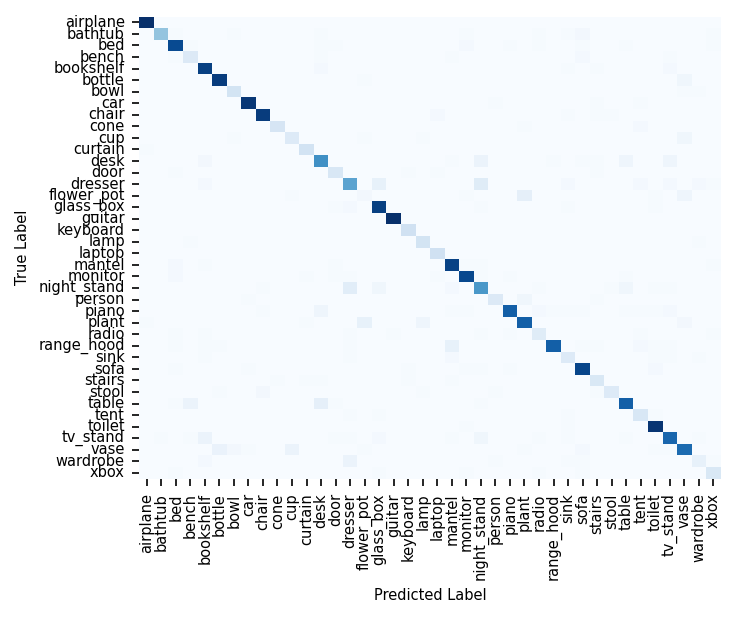

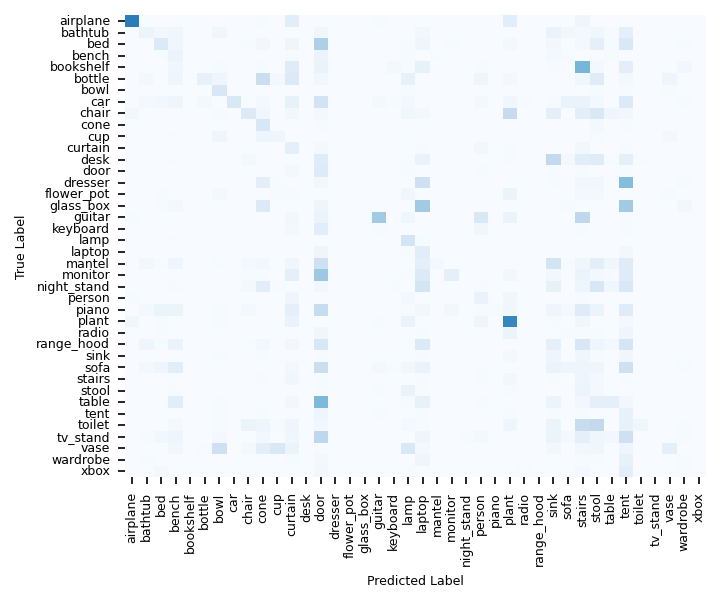

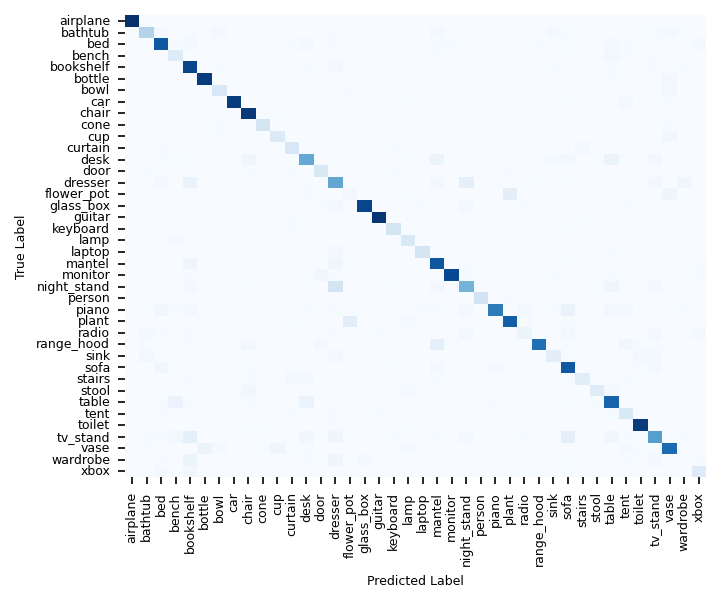

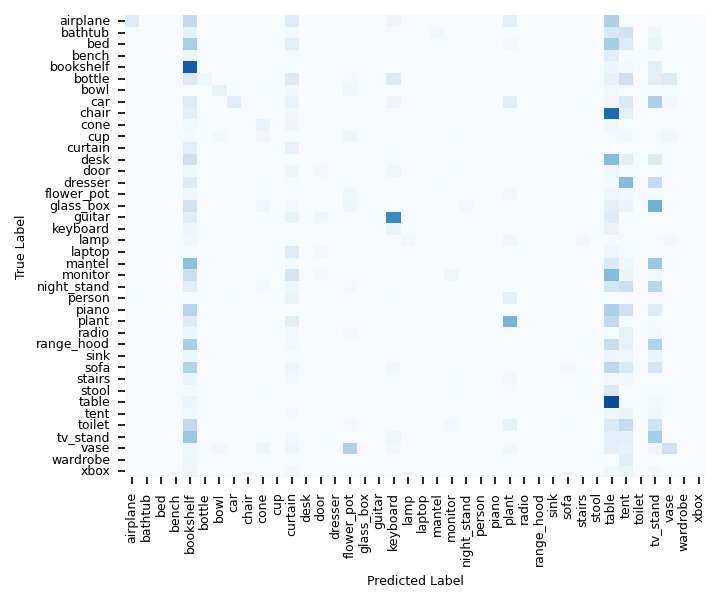

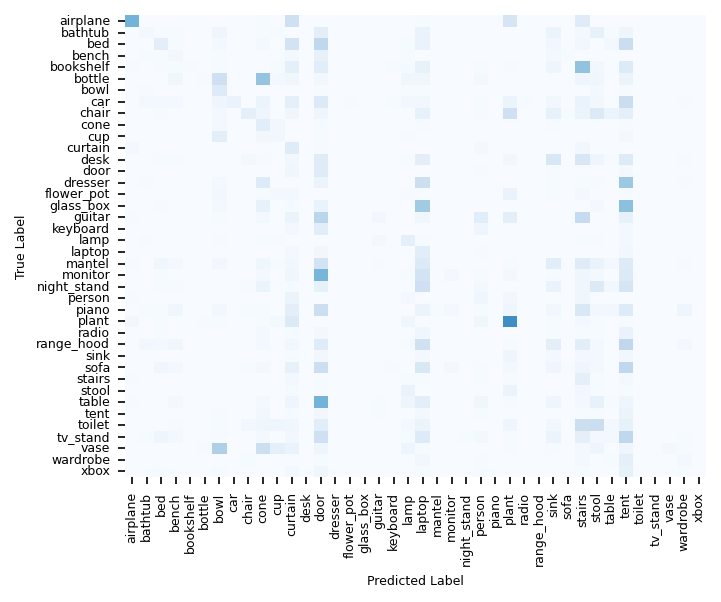

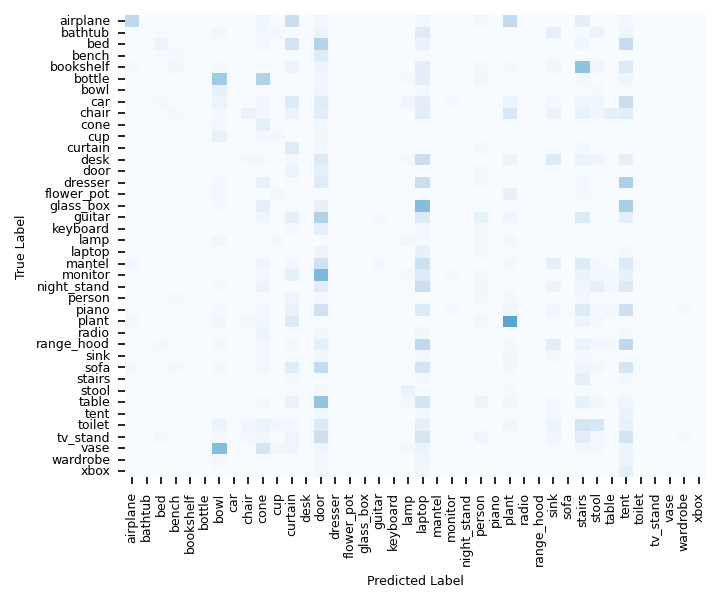

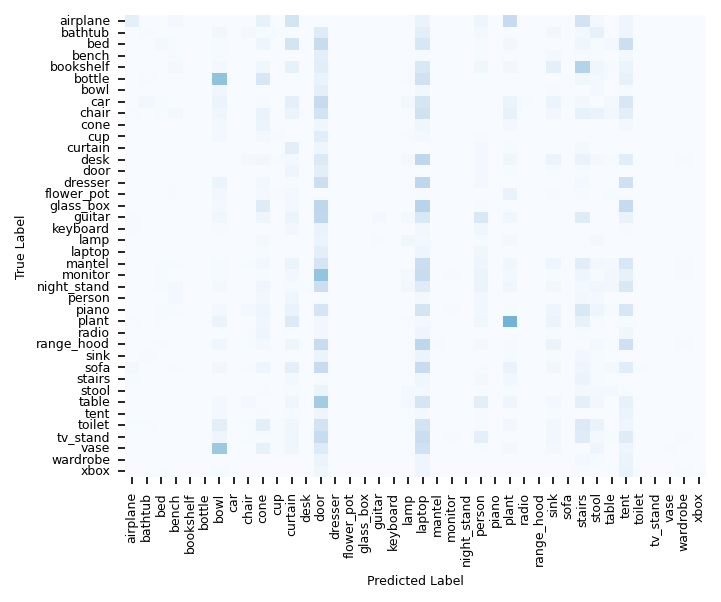

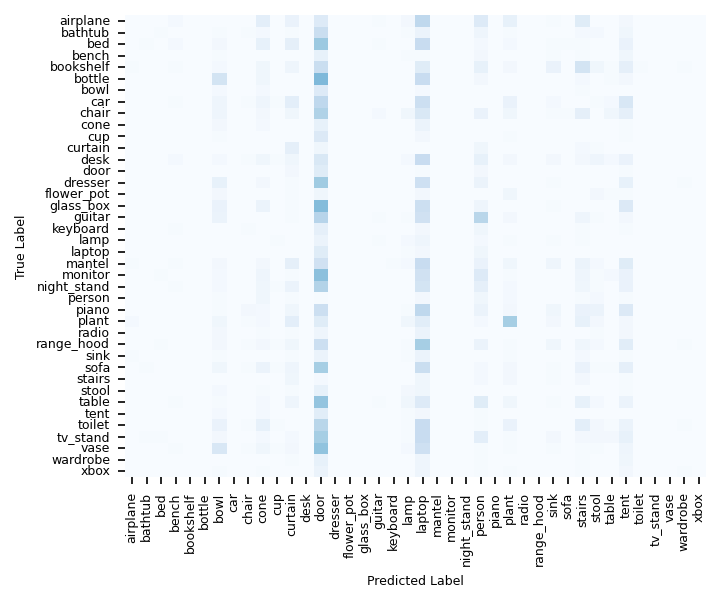

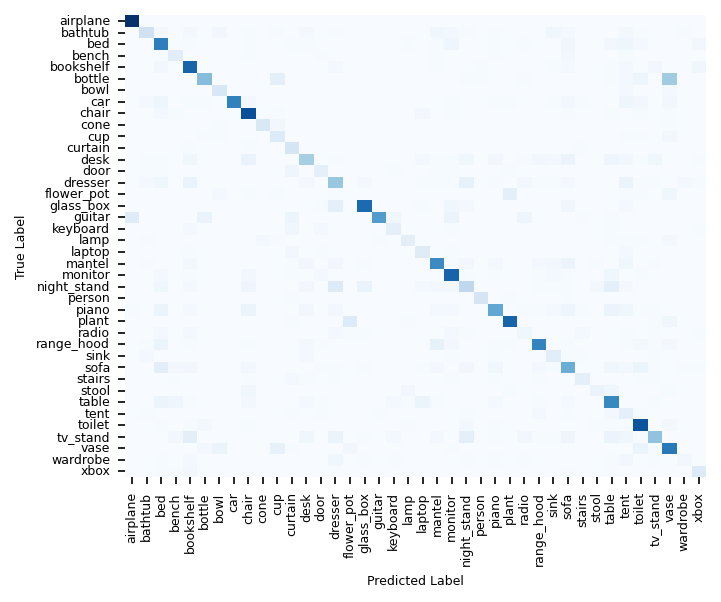

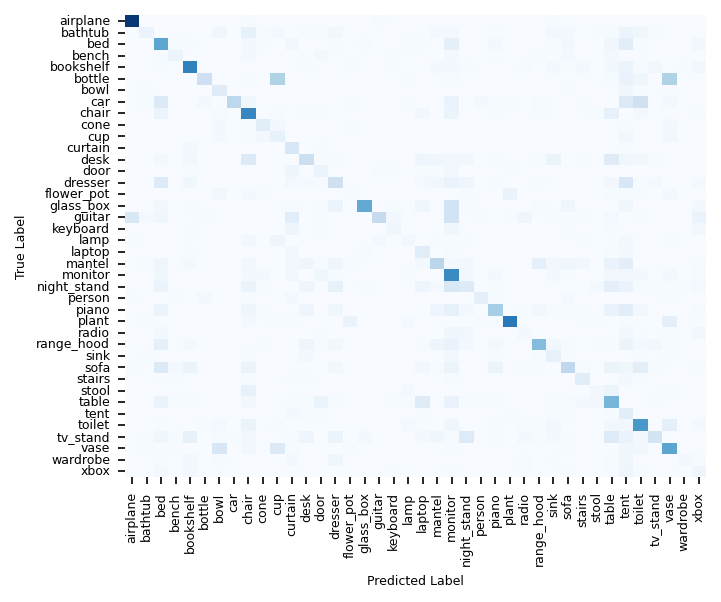

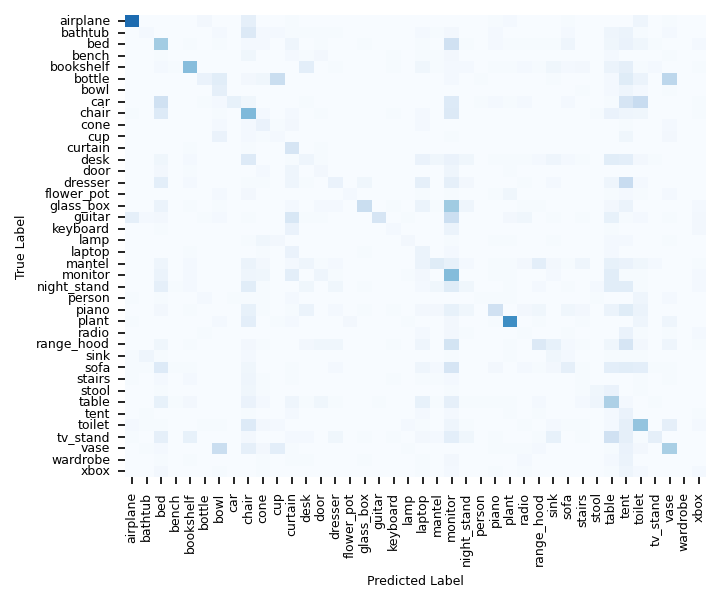

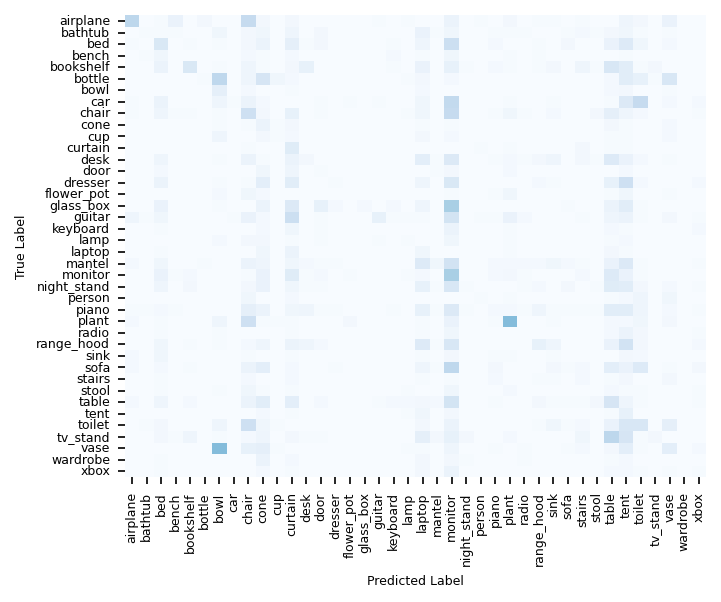

In [23]:
def make_confusion_matrix_small(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4), dpi=150)
    plt.rcParams.update({'font.size': 6})
    ax = sns.heatmap(
        data=cm,
        annot=False,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names.values(),
        yticklabels=class_names.values(),
        ax=ax,
        vmax=100,
        vmin=0,
        cbar=False
      )
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

    return fig, ax


# Make the confusion matrix for all results, save to output folder
for col in tqdm(columns, desc='Drawing Confusion Matrices'):
  model, test = col.split('_')
  y_true = result_df['y_true']
  y_pred = result_df[col]
  fig, ax = make_confusion_matrix_small(y_true, y_pred, class_names)
  ax.set_title('')
  fig.savefig(os.path.join(results_dir, f'v2_cm_{model}_trained_{test}_tested_small.png'), bbox_inches='tight')